<a href="https://colab.research.google.com/github/KBM5703/2111464_Tran-Vi-Khang/blob/main/Copy_of_Khang_ISSAS25.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SETUP REPO

In [1]:
!pip install -q ipympl

In [2]:
from google.colab import userdata
GITHUB_PAT=userdata.get('GITHUB_PAT')

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import os
import sys

# Cấu hình GitHub
GITHUB_REPO = 'hieuphmm/ISAS_Challenge2025'
REPO_DIR = os.path.basename(GITHUB_REPO)
BRANCH = "exp/khang"

# Clone repo
%cd /content
!git clone https://{GITHUB_PAT}@github.com/{GITHUB_REPO}.git {REPO_DIR}
%cd {REPO_DIR}

# Tạo nhánh nếu chưa có (checkout -b để tạo mới)
!git checkout -b {BRANCH}

# Push nhánh mới lên GitHub
!git push -u origin {BRANCH}

# Thêm repo vào sys.path để import module nội bộ
sys.path.append(os.getcwd())

/content
fatal: destination path 'ISAS_Challenge2025' already exists and is not an empty directory.
/content/ISAS_Challenge2025
fatal: A branch named 'exp/khang' already exists.
To https://github.com/hieuphmm/ISAS_Challenge2025.git
 ! [rejected]        exp/khang -> exp/khang (non-fast-forward)
error: failed to push some refs to 'https://github.com/hieuphmm/ISAS_Challenge2025.git'
hint: Updates were rejected because the tip of your current branch is behind
hint: its remote counterpart. Integrate the remote changes (e.g.
hint: 'git pull ...') before pushing again.
hint: See the 'Note about fast-forwards' in 'git push --help' for details.


# SIMPLE WORKFLOW

## 1. Import and data

In [5]:
%load_ext autoreload
%autoreload 2

In [6]:
sys.path

['/content',
 '/env/python',
 '/usr/lib/python311.zip',
 '/usr/lib/python3.11',
 '/usr/lib/python3.11/lib-dynload',
 '',
 '/usr/local/lib/python3.11/dist-packages',
 '/usr/lib/python3/dist-packages',
 '/usr/local/lib/python3.11/dist-packages/IPython/extensions',
 '/usr/local/lib/python3.11/dist-packages/setuptools/_vendor',
 '/root/.ipython',
 '/content/ISAS_Challenge2025']

In [7]:
import os
import sys

import numpy as np
import pandas as pd
from src import DATA_DIR
from src.constants import ACTIVITY_LABEL_MAP, SEQUENCE_LENGTH
from src.constants import SEQUENCE_LENGTH_IN_WINDOW, WINDOW_OVERLAP_RATE, WINDOW_SIZE
from src.utils import create_sequences

import torch
import torch.nn
from torch.utils.data import Dataset, DataLoader
import gdown


In [8]:
CHALLENGE_DATA_DIR = os.path.join(DATA_DIR)  # /content/ISAS_Challenge2025/data

KEYPOINT_DIR = os.path.join(CHALLENGE_DATA_DIR, "keypoint-20250616T140515Z-1-001", "keypoint")
KEYPOINT_LABEL_DIR = os.path.join(CHALLENGE_DATA_DIR, "keypointlabel-20250616T140517Z-1-001", "keypointlabel")
TIME_TABLE_DIR = os.path.join(CHALLENGE_DATA_DIR, "timetable-20250616T140520Z-1-001", "timetable")

print(KEYPOINT_DIR, os.path.exists(KEYPOINT_DIR))
print(KEYPOINT_LABEL_DIR, os.path.exists(KEYPOINT_LABEL_DIR))
print(TIME_TABLE_DIR, os.path.exists(TIME_TABLE_DIR))


/content/ISAS_Challenge2025/data/keypoint-20250616T140515Z-1-001/keypoint True
/content/ISAS_Challenge2025/data/keypointlabel-20250616T140517Z-1-001/keypointlabel True
/content/ISAS_Challenge2025/data/timetable-20250616T140520Z-1-001/timetable True


In [9]:
# download dataset
DATASET_URL = "https://drive.google.com/drive/folders/1xXo0dPWcPAwDQsXJGNEYofeFOO2iBtM6?usp=sharing"
if os.path.exists(KEYPOINT_DIR) and os.path.exists(KEYPOINT_LABEL_DIR):
    print("Dataset already downloaded")
else:
    print("Downloading dataset...")
    _ = gdown.download_folder(url=DATASET_URL, output=DATA_DIR)

Dataset already downloaded


## 2. Data exploration

### 2.1 Visualization

In [10]:
csv_paths = []
for r, _, fs in os.walk(KEYPOINT_LABEL_DIR):
    for f in fs:
        csv_paths.append(os.path.join(r, f))
    break
csv_paths = sorted(csv_paths)
csv_paths

['/content/ISAS_Challenge2025/data/keypointlabel-20250616T140517Z-1-001/keypointlabel/keypoints_with_labels_1.csv',
 '/content/ISAS_Challenge2025/data/keypointlabel-20250616T140517Z-1-001/keypointlabel/keypoints_with_labels_2.csv',
 '/content/ISAS_Challenge2025/data/keypointlabel-20250616T140517Z-1-001/keypointlabel/keypoints_with_labels_3.csv',
 '/content/ISAS_Challenge2025/data/keypointlabel-20250616T140517Z-1-001/keypointlabel/keypoints_with_labels_5.csv']

In [11]:
test_path = csv_paths[0]
df = pd.read_csv(test_path)
df.head()

,frame_id,nose_x,nose_y,left_eye_x,left_eye_y,right_eye_x,right_eye_y,left_ear_x,left_ear_y,right_ear_x,...,right_hip_y,left_knee_x,left_knee_y,right_knee_x,right_knee_y,left_ankle_x,left_ankle_y,right_ankle_x,right_ankle_y,Action Label
0,0,624.0,258.25,628.0,249.50,625.0,249.750,650.5,252.250,667.5,...,441.00,656.5,535.0,724.0,528.0,634.5,616.5,746.5,612.0,Walking
1,1,618.0,260.00,621.5,251.25,618.5,251.625,644.0,254.375,660.5,...,440.00,651.0,533.5,720.0,526.5,627.5,616.0,746.0,610.5,Walking
2,2,611.5,260.50,615.0,252.00,613.0,252.250,637.0,256.000,656.5,...,441.00,644.5,533.0,715.5,525.5,625.5,616.5,746.0,609.5,Walking
3,3,604.0,261.00,608.0,252.50,605.5,252.750,630.5,256.000,648.5,...,443.00,639.0,535.0,710.5,525.5,623.0,618.0,745.5,608.0,Walking
4,4,598.0,260.00,602.5,252.00,600.0,252.000,623.0,256.750,642.5,...,444.25,634.5,539.0,703.0,525.5,620.5,619.0,742.5,605.5,Walking


In [12]:
value = df.drop(columns=["frame_id", "Action Label"])
value = value.values
value.shape, value[0]

((76456, 34),
 array([624.   , 258.25 , 628.   , 249.5  , 625.   , 249.75 , 650.5  ,
        252.25 , 667.5  , 249.125, 666.   , 309.5  , 691.5  , 297.5  ,
        674.   , 391.   , 696.   , 380.   , 673.   , 463.   , 679.   ,
        448.5  , 678.   , 447.   , 707.5  , 441.   , 656.5  , 535.   ,
        724.   , 528.   , 634.5  , 616.5  , 746.5  , 612.   ]))

In [13]:
from google.colab import output
output.enable_custom_widget_manager()

interactive(children=(IntSlider(value=0, description='Frame', layout=Layout(width='600px'), max=76455), Output…

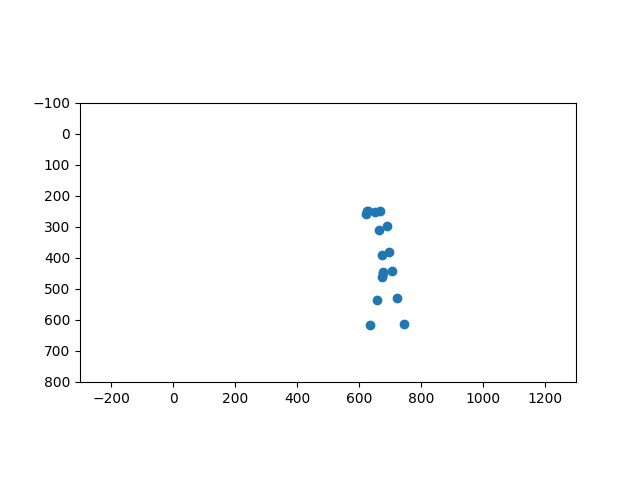

In [14]:
%matplotlib widget
import matplotlib.pyplot as plt
import numpy as np
from ipywidgets import interact, IntSlider, Play, VBox, HBox, jslink, Dropdown, BoundedIntText
from IPython.display import display

# --- Matplotlib setup ---
fig, ax = plt.subplots()
sc = ax.scatter([], [])  # init scatter
sc.set_offsets(np.column_stack((value[0, 0::2], value[0, 1::2])))  # <- THÊM DÒNG NÀY

ax.set_xlim(-300, 1300)
ax.set_ylim(-100, 800)
ax.invert_yaxis()
ax.axis('scaled')

# --- Widgets ---
slider = IntSlider(value=0, min=0, max=len(value)-1, description='Frame', layout={'width': '600px'})
play = Play(min=0, max=len(value)-1, interval=33, step=1, layout={'width': '600px'})

speed_dropdown = Dropdown(
    options=[('🐢 15 FPS', 67), ('🏃 30 FPS', 33), ('🚀 60 FPS', 17), ('⚡ Ultra Fast', 1)],
    value=33,
    description='Speed:',
    layout={'width': '300px'}
)

step_spinner = BoundedIntText(
    value=1, min=1, max=100, step=1,
    description='Frame step:', layout={'width': '200px'}
)

# --- Event bindings ---
def on_speed_change(change): play.interval = change['new']
def on_skip_change(change): play.step = change['new']

speed_dropdown.observe(on_speed_change, names='value')
step_spinner.observe(on_skip_change, names='value')
jslink((play, 'value'), (slider, 'value'))

# --- Update function ---
def update(idx):
    sc.set_offsets(np.column_stack((value[idx, 0::2], value[idx, 1::2])))
    fig.canvas.draw_idle()

interact(update, idx=slider)
display(VBox([slider, play, HBox([speed_dropdown, step_spinner])]))


In [15]:
from google.colab import output
output.disable_custom_widget_manager()

### 2.2 Data processing

In [16]:
print(ACTIVITY_LABEL_MAP)

def fix_label(label:str):
    if label == "Throwing":
        return "Throwing things"
    return label

{0: 'Sitting quietly', 1: 'Using phone', 2: 'Walking', 3: 'Eating snacks', 4: 'Head banging', 5: 'Throwing things', 6: 'Attacking', 7: 'Biting'}


In [17]:
# fix label Throwing -> Throwing things
csv_dir = KEYPOINT_LABEL_DIR
out_dir = os.path.join(CHALLENGE_DATA_DIR, "keypointlabelcleaned")
os.makedirs(out_dir, exist_ok=True)

cleaned_csv_paths = []
# total_df = pd.DataFrame()
for filename in os.listdir(csv_dir):
    csv_path = os.path.join(csv_dir, filename)
    df = pd.read_csv(csv_path)
    df["Action Label"] = df["Action Label"].apply(fix_label)
    df = df.dropna()  # DROP NA

    dst = f"cleaned_{filename}"
    dst = os.path.join(out_dir, dst)
    cleaned_csv_paths.append(dst)
    df.to_csv(dst,index=False)
    # total_df = pd.concat([total_df, df])

cleaned_csv_paths = sorted(cleaned_csv_paths)

In [18]:
def process_data(
    df: pd.DataFrame,
    window_size: int,
    sequence_length_in_window: int,
    window_overlap_rate: float = 0.5,
    window_padding: bool = True,
    sequence_overlap_rate: float = 0.0,
    sequence_padding: bool = True,
):
    # df = pd.read_csv(cleaned_csv_paths[0])
    def _create_sequences(data):
        return create_sequences(
            data=data,
            window_size=window_size,
            sequence_length_in_window=sequence_length_in_window,
            window_overlap_rate=window_overlap_rate,
            window_padding=sequence_padding,
            sequence_overlap_rate=sequence_overlap_rate,
            sequence_padding=window_padding,
        )

    frame_id = df["frame_id"].values
    diff = frame_id[1:] - frame_id[:-1]
    diff_idx = np.flatnonzero(diff != 1) + 1

    labels = df["Action Label"].values
    features = df[df.columns[1:-1]]  # remove "frame_id" and "Actual Label"

    XY = []
    for i in range(0, len(diff_idx) - 1):
        first_idx, last_idx = diff_idx[i], diff_idx[i + 1]
        sequences = _create_sequences(features[first_idx:last_idx])
        Y = [labels[first_idx]] * sequences.shape[0]
        XY.append((sequences, Y))
    # 1st sequence
    sequences = _create_sequences(data=features[: diff_idx[0]])
    Y = [labels[0]] * sequences.shape[0]
    XY.insert(0, (sequences, Y))
    # last squence
    sequences = _create_sequences(data=features[diff_idx[-1] :])
    Y = [labels[-1]] * sequences.shape[0]
    XY.append((sequences, Y))
    return XY

In [19]:
print(cleaned_csv_paths[0])
df = pd.read_csv(cleaned_csv_paths[0])
XY = process_data(
    df=df,
    window_size=WINDOW_SIZE,
    sequence_length_in_window=SEQUENCE_LENGTH_IN_WINDOW,
    window_overlap_rate=WINDOW_OVERLAP_RATE,
    window_padding=True,
    sequence_overlap_rate=0,
    sequence_padding=False,
)

/content/ISAS_Challenge2025/data/keypointlabelcleaned/cleaned_keypoints_with_labels_1.csv


In [20]:
for X, Y in XY:
    print(X.shape)
    print(X)
    print(len(Y))
    print(Y[0], Y[-1])
    break

(164, 3, 30, 34)
[[[[624.      258.25    628.      ... 616.5     746.5     612.     ]
   [618.      260.      621.5     ... 616.      746.      610.5    ]
   [611.5     260.5     615.      ... 616.5     746.      609.5    ]
   ...
   [440.75    268.      444.      ... 591.5     516.      596.     ]
   [434.5     269.25    437.5     ... 592.      518.      597.     ]
   [429.      268.5     432.      ... 594.      520.5     595.     ]]

  [[517.5     264.      521.      ... 615.5     609.5     581.5    ]
   [510.      265.      514.      ... 611.5     596.      588.     ]
   [502.75    265.25    506.25    ... 614.      574.      590.     ]
   ...
   [348.      278.      351.5     ... 603.      504.      579.     ]
   [341.      277.25    344.      ... 604.      496.75    574.5    ]
   [334.25    278.5     337.      ... 607.      489.      570.     ]]

  [[425.      268.5     427.5     ... 588.      526.5     587.     ]
   [417.25    269.      420.5     ... 595.      518.5     592.     ]

## 3. Modeling

In [21]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [22]:
import os
import pandas as pd
import numpy as np
from math import acos, degrees

# === CONFIG ===
INPUT_FOLDER = '/content/ISAS_Challenge2025/data/keypointlabelcleaned'
OUTPUT_FOLDER = 'features'
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

# === Hành vi và loại độ dài ===
action_type = {
    "Sitting quietly": "normal",
    "Using phone": "normal",
    "Walking": "normal",
    "Eating snacks": "normal",
    "Head banging": "unusual",
    "Throwing things": "unusual",
    "Attacking": "unusual",
    "Biting nails": "unusual"
}

def get_window_params(action_label):
    if action_type.get(action_label, "normal") == "unusual":
        return 30, 10  # window=30, step=10
    else:
        return 60, 20  # window=60, step=20

# === TÍNH TOÁN FEATURE ===
def calculate_speed(positions):
    positions = np.array(positions)
    if len(positions) < 2:
        return 0.0
    diffs = np.diff(positions, axis=0)
    return np.linalg.norm(diffs, axis=1).mean()

def calculate_acceleration(positions):
    positions = np.array(positions)
    if len(positions) < 3:
        return 0.0
    velocity = np.diff(positions, axis=0)
    acceleration = np.diff(velocity, axis=0)
    return np.linalg.norm(acceleration, axis=1).mean()

def calculate_angle(p1, p2, p3):
    v1 = np.array(p1) - np.array(p2)
    v2 = np.array(p3) - np.array(p2)
    cos_angle = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
    return degrees(acos(np.clip(cos_angle, -1.0, 1.0)))

def calculate_vertical_movement(positions):
    y = np.array([p[1] for p in positions])
    return y.max() - y.min()

def calculate_horizontal_movement(positions):
    x = np.array([p[0] for p in positions])
    return x.max() - x.min()

def calculate_displacement(positions):
    positions = np.array(positions)
    return np.sum(np.linalg.norm(np.diff(positions, axis=0), axis=1))

def calculate_jerk(positions):
    positions = np.array(positions)
    if len(positions) < 4:
        return 0.0
    vel = np.diff(positions, axis=0)
    acc = np.diff(vel, axis=0)
    jerk = np.diff(acc, axis=0)
    return np.linalg.norm(jerk, axis=1).mean()

def calculate_distance(p1, p2):
    return np.linalg.norm(np.array(p1) - np.array(p2))

def extract_window_features(window):
    window = window.to_dict('records')
    def get_pos(joint):
        return [(f[f'{joint}_x'], f[f'{joint}_y']) for f in window]

    right_hand = get_pos('right_wrist')
    left_hand = get_pos('left_wrist')
    right_foot = get_pos('right_ankle')
    left_foot = get_pos('left_ankle')
    right_eye = get_pos('right_eye')
    left_eye = get_pos('left_eye')
    right_shoulder = get_pos('right_shoulder')
    left_shoulder = get_pos('left_shoulder')

    return {
        'action': window[-1]['Action Label'],
        'right_hand_speed': calculate_speed(right_hand),
        'left_hand_speed': calculate_speed(left_hand),
        'right_hand_acceleration': calculate_acceleration(right_hand),
        'left_hand_acceleration': calculate_acceleration(left_hand),
        'right_shoulder_wrist_angle': calculate_angle(right_shoulder[0], right_hand[0], right_hand[-1]),
        'left_shoulder_wrist_angle': calculate_angle(left_shoulder[0], left_hand[0], left_hand[-1]),
        'right_eye_vertical_movement': calculate_vertical_movement(right_eye),
        'left_eye_vertical_movement': calculate_vertical_movement(left_eye),
        'right_eye_horizontal_movement': calculate_horizontal_movement(right_eye),
        'left_eye_horizontal_movement': calculate_horizontal_movement(left_eye),
        'right_hand_eye_distance': calculate_distance(right_hand[0], right_eye[0]),
        'left_hand_eye_distance': calculate_distance(left_hand[0], left_eye[0]),
        'right_foot_speed': calculate_speed(right_foot),
        'left_foot_speed': calculate_speed(left_foot),
        'right_hand_displacement': calculate_displacement(right_hand),
        'left_hand_displacement': calculate_displacement(left_hand),
        'right_hand_jerk': calculate_jerk(right_hand),
        'left_hand_jerk': calculate_jerk(left_hand),
        'right_foot_displacement': calculate_displacement(right_foot),
        'left_foot_displacement': calculate_displacement(left_foot),
    }

# === XỬ LÝ TOÀN BỘ FILE ===
for file in os.listdir(INPUT_FOLDER):
    if not file.endswith('.csv'):
        continue

    df = pd.read_csv(os.path.join(INPUT_FOLDER, file))
    feature_rows = []

    for action in df['Action Label'].unique():
        sub_df = df[df['Action Label'] == action].reset_index(drop=True)
        win_size, step_size = get_window_params(action)

        for start in range(0, len(sub_df) - win_size + 1, step_size):
            window = sub_df.iloc[start:start + win_size]
            feat = extract_window_features(window)
            feature_rows.append(feat)

    feature_df = pd.DataFrame(feature_rows)
    output_path = os.path.join(OUTPUT_FOLDER, file.replace('.csv', '_features.csv'))
    feature_df.to_csv(output_path, index=False)
    print(f"✅ Extracted adaptive features from {file} → {output_path}")


/tmp/ipython-input-22-1611121443.py:48: RuntimeWarning: invalid value encountered in scalar divide
  cos_angle = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
/tmp/ipython-input-22-1611121443.py:48: RuntimeWarning: invalid value encountered in scalar divide
  cos_angle = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
/tmp/ipython-input-22-1611121443.py:48: RuntimeWarning: invalid value encountered in scalar divide
  cos_angle = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
/tmp/ipython-input-22-1611121443.py:48: RuntimeWarning: invalid value encountered in scalar divide
  cos_angle = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
/tmp/ipython-input-22-1611121443.py:48: RuntimeWarning: invalid value encountered in scalar divide
  cos_angle = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
/tmp/ipython-input-22-1611121443.py:48: RuntimeWarning: invalid value encountered in scalar divide
  cos_angle = np.dot(v1, v2) / (np.linalg

✅ Extracted adaptive features from cleaned_keypoints_with_labels_1.csv → features/cleaned_keypoints_with_labels_1_features.csv


/tmp/ipython-input-22-1611121443.py:48: RuntimeWarning: invalid value encountered in scalar divide
  cos_angle = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
/tmp/ipython-input-22-1611121443.py:48: RuntimeWarning: invalid value encountered in scalar divide
  cos_angle = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
/tmp/ipython-input-22-1611121443.py:48: RuntimeWarning: invalid value encountered in scalar divide
  cos_angle = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
/tmp/ipython-input-22-1611121443.py:48: RuntimeWarning: invalid value encountered in scalar divide
  cos_angle = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
/tmp/ipython-input-22-1611121443.py:48: RuntimeWarning: invalid value encountered in scalar divide
  cos_angle = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
/tmp/ipython-input-22-1611121443.py:48: RuntimeWarning: invalid value encountered in scalar divide
  cos_angle = np.dot(v1, v2) / (np.linalg

✅ Extracted adaptive features from cleaned_keypoints_with_labels_2.csv → features/cleaned_keypoints_with_labels_2_features.csv


/tmp/ipython-input-22-1611121443.py:48: RuntimeWarning: invalid value encountered in scalar divide
  cos_angle = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
/tmp/ipython-input-22-1611121443.py:48: RuntimeWarning: invalid value encountered in scalar divide
  cos_angle = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
/tmp/ipython-input-22-1611121443.py:48: RuntimeWarning: invalid value encountered in scalar divide
  cos_angle = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
/tmp/ipython-input-22-1611121443.py:48: RuntimeWarning: invalid value encountered in scalar divide
  cos_angle = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
/tmp/ipython-input-22-1611121443.py:48: RuntimeWarning: invalid value encountered in scalar divide
  cos_angle = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
/tmp/ipython-input-22-1611121443.py:48: RuntimeWarning: invalid value encountered in scalar divide
  cos_angle = np.dot(v1, v2) / (np.linalg

✅ Extracted adaptive features from cleaned_keypoints_with_labels_5.csv → features/cleaned_keypoints_with_labels_5_features.csv


/tmp/ipython-input-22-1611121443.py:48: RuntimeWarning: invalid value encountered in scalar divide
  cos_angle = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
/tmp/ipython-input-22-1611121443.py:48: RuntimeWarning: invalid value encountered in scalar divide
  cos_angle = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
/tmp/ipython-input-22-1611121443.py:48: RuntimeWarning: invalid value encountered in scalar divide
  cos_angle = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
/tmp/ipython-input-22-1611121443.py:48: RuntimeWarning: invalid value encountered in scalar divide
  cos_angle = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
/tmp/ipython-input-22-1611121443.py:48: RuntimeWarning: invalid value encountered in scalar divide
  cos_angle = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
/tmp/ipython-input-22-1611121443.py:48: RuntimeWarning: invalid value encountered in scalar divide
  cos_angle = np.dot(v1, v2) / (np.linalg

✅ Extracted adaptive features from cleaned_keypoints_with_labels_3.csv → features/cleaned_keypoints_with_labels_3_features.csv


✅ Epoch 1: 🔥 New best model saved with F1: 0.7704

📂 Fold: Train on [2, 3, 5], Test on [1]
  Accuracy : 0.7710
  Precision: 0.7708
  Recall   : 0.7710
  F1 Score : 0.7704
  Log Loss : 0.5684

🧩 Confusion Matrix:
                 Attacking  Head banging  Throwing things
Attacking              332            10              103
Head banging             3           354               22
Throwing things        138            16              297


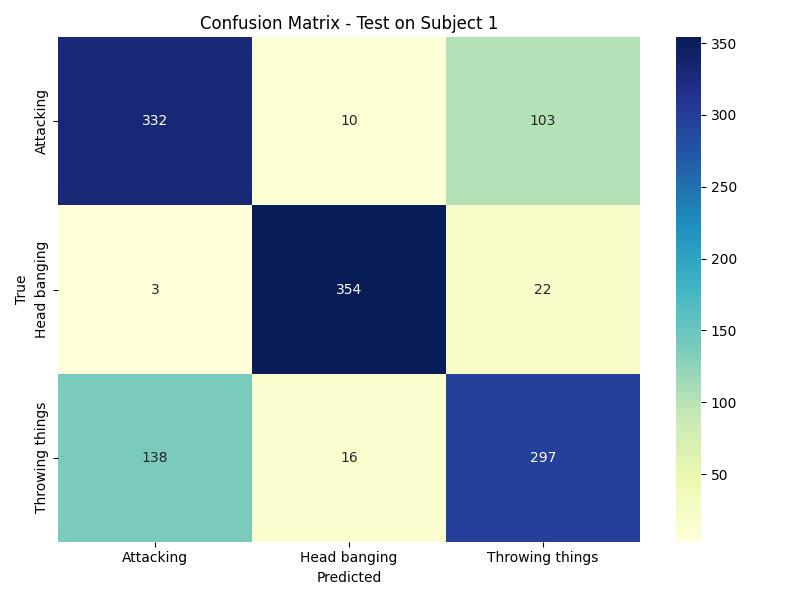


📄 Classification Report:
                 precision    recall  f1-score   support

      Attacking       0.70      0.75      0.72       445
   Head banging       0.93      0.93      0.93       379
Throwing things       0.70      0.66      0.68       451

       accuracy                           0.77      1275
      macro avg       0.78      0.78      0.78      1275
   weighted avg       0.77      0.77      0.77      1275

✅ Epoch 1: 🔥 New best model saved with F1: 0.5449
✅ Epoch 2: 🔥 New best model saved with F1: 0.7103
✅ Epoch 3: 🔥 New best model saved with F1: 0.7601
✅ Epoch 4: 🔥 New best model saved with F1: 0.7675
✅ Epoch 11: 🔥 New best model saved with F1: 0.7918
✅ Epoch 18: 🔥 New best model saved with F1: 0.8065

📂 Fold: Train on [1, 3, 5], Test on [2]
  Accuracy : 0.8124
  Precision: 0.8060
  Recall   : 0.8124
  F1 Score : 0.8065
  Log Loss : 0.4546

🧩 Confusion Matrix:
                 Attacking  Head banging  Throwing things
Attacking              478             9          

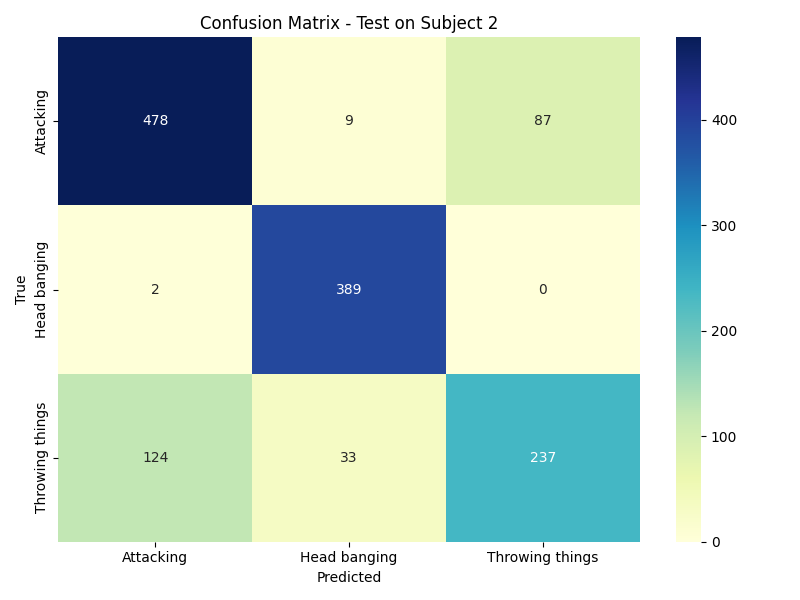


📄 Classification Report:
                 precision    recall  f1-score   support

      Attacking       0.79      0.83      0.81       574
   Head banging       0.90      0.99      0.95       391
Throwing things       0.73      0.60      0.66       394

       accuracy                           0.81      1359
      macro avg       0.81      0.81      0.81      1359
   weighted avg       0.81      0.81      0.81      1359

✅ Epoch 1: 🔥 New best model saved with F1: 0.7722
✅ Epoch 7: 🔥 New best model saved with F1: 0.8111

📂 Fold: Train on [1, 2, 5], Test on [3]
  Accuracy : 0.8064
  Precision: 0.8252
  Recall   : 0.8064
  F1 Score : 0.8111
  Log Loss : 0.5754

🧩 Confusion Matrix:
                 Attacking  Head banging  Throwing things
Attacking              460             0               72
Head banging            38           507               74
Throwing things        106             5              262


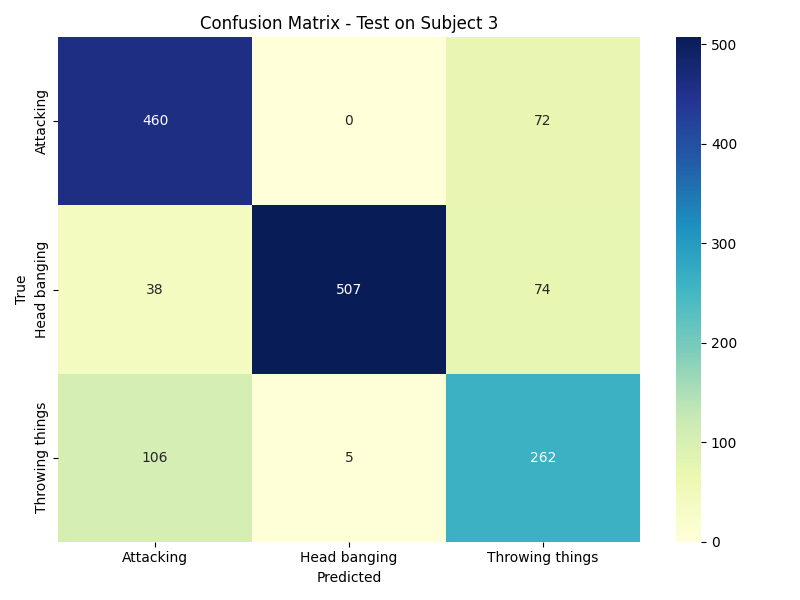


📄 Classification Report:
                 precision    recall  f1-score   support

      Attacking       0.76      0.86      0.81       532
   Head banging       0.99      0.82      0.90       619
Throwing things       0.64      0.70      0.67       373

       accuracy                           0.81      1524
      macro avg       0.80      0.80      0.79      1524
   weighted avg       0.83      0.81      0.81      1524

✅ Epoch 1: 🔥 New best model saved with F1: 0.8803
✅ Epoch 2: 🔥 New best model saved with F1: 0.8965
✅ Epoch 3: 🔥 New best model saved with F1: 0.9260
✅ Epoch 4: 🔥 New best model saved with F1: 0.9412
✅ Epoch 6: 🔥 New best model saved with F1: 0.9420
✅ Epoch 8: 🔥 New best model saved with F1: 0.9469
✅ Epoch 9: 🔥 New best model saved with F1: 0.9510

📂 Fold: Train on [1, 2, 3], Test on [5]
  Accuracy : 0.9510
  Precision: 0.9511
  Recall   : 0.9510
  F1 Score : 0.9510
  Log Loss : 0.1652

🧩 Confusion Matrix:
                 Attacking  Head banging  Throwing things
At

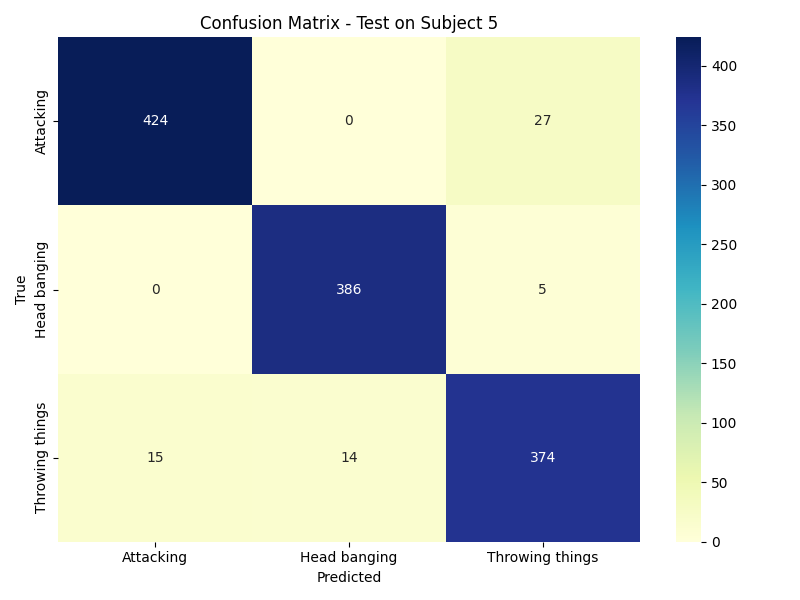


📄 Classification Report:
                 precision    recall  f1-score   support

      Attacking       0.97      0.94      0.95       451
   Head banging       0.96      0.99      0.98       391
Throwing things       0.92      0.93      0.92       403

       accuracy                           0.95      1245
      macro avg       0.95      0.95      0.95      1245
   weighted avg       0.95      0.95      0.95      1245


📊 === KẾT QUẢ TRUNG BÌNH LOSO (MLP) ===
Accuracy  : 0.8352
Precision : 0.8383
Recall    : 0.8352
F1        : 0.8347
Log_loss  : 0.4409


In [23]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, log_loss, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils.class_weight import compute_class_weight
# ==== CONFIG ====
subject_ids = [1, 2, 3, 5]
data_dir = "features"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_dim = 20
hidden_dim = 64
num_epochs = 50
batch_size = 32
lr = 1e-3

# ==== MLP Model ====
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes):
        super(MLP, self).__init__()
        self.model = nn.Sequential(
      nn.Linear(input_dim, hidden_dim),
      nn.BatchNorm1d(hidden_dim),
      nn.ReLU(),
      nn.Dropout(0.3),
      nn.Linear(hidden_dim, hidden_dim),
      nn.BatchNorm1d(hidden_dim),
      nn.ReLU(),
      nn.Dropout(0.3),
      nn.Linear(hidden_dim, num_classes)
  )

    def forward(self, x):
        return self.model(x)

# ==== Training function ====
def train_model(model, train_loader, criterion, optimizer):
    model.train()
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

# ==== Evaluation function ====
def evaluate_model(model, X_test, y_test):
    model.eval()
    with torch.no_grad():
        X_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
        outputs = model(X_tensor)
        y_pred = outputs.argmax(dim=1).cpu().numpy()
        y_proba = torch.softmax(outputs, dim=1).cpu().numpy()
    return y_pred, y_proba

# ==== LOSO Training ====
all_metrics = {"accuracy": [], "precision": [], "recall": [], "f1": [], "log_loss": []}

for test_id in subject_ids:
    # Load data
    df_test = pd.read_csv(f"{data_dir}/cleaned_keypoints_with_labels_{test_id}_features.csv")
    df_train = pd.concat([
        pd.read_csv(f"{data_dir}/cleaned_keypoints_with_labels_{i}_features.csv")
        for i in subject_ids if i != test_id
    ], ignore_index=True)

    # === Chỉ lấy abnormal actions ===
    abnormal_labels = ['Head banging', 'Throwing things', 'Attacking', 'Biting nails']
    df_train = df_train[df_train['action'].isin(abnormal_labels)].copy()
    df_test = df_test[df_test['action'].isin(abnormal_labels)].copy()

    # === Tiếp tục như cũ ===
    X_train, y_train = df_train.drop(columns=["action"]), df_train["action"]
    X_test, y_test = df_test.drop(columns=["action"]), df_test["action"]

    # Encode label
    le = LabelEncoder()
    y_train_enc = le.fit_transform(y_train)
    y_test_enc = le.transform(y_test)  # Không còn lỗi unseen class vì đã lọc rồi

    # Impute missing values
    imputer = SimpleImputer(strategy='mean')
    X_train = imputer.fit_transform(X_train)
    X_test = imputer.transform(X_test)

    # Standardize
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    num_classes = len(le.classes_)

    # PyTorch DataLoader
    train_dataset = torch.utils.data.TensorDataset(
        torch.tensor(X_train, dtype=torch.float32),
        torch.tensor(y_train_enc, dtype=torch.long)
    )
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    # Model init
    model = MLP(input_dim=input_dim, hidden_dim=hidden_dim, num_classes=num_classes).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    weights = compute_class_weight('balanced', classes=np.unique(y_train_enc), y=y_train_enc)
    criterion = nn.CrossEntropyLoss(weight=torch.tensor(weights, dtype=torch.float32).to(device))

    # Train
    best_model_path = f"best_model_subject_{test_id}.pt"
    best_f1 = 0.0

    for epoch in range(num_epochs):
        train_model(model, train_loader, criterion, optimizer)

        # Evaluate mỗi epoch trên tập test
        y_pred_epoch, _ = evaluate_model(model, X_test, y_test_enc)
        f1_epoch = f1_score(y_test_enc, y_pred_epoch, average='weighted', zero_division=0)

        # Lưu nếu tốt hơn
        if f1_epoch > best_f1:
            best_f1 = f1_epoch
            torch.save(model.state_dict(), best_model_path)
            print(f"✅ Epoch {epoch+1}: 🔥 New best model saved with F1: {f1_epoch:.4f}")
    model.load_state_dict(torch.load(best_model_path))
    # Predict
    y_pred, y_proba = evaluate_model(model, X_test, y_test_enc)

    # Metrics
    acc = accuracy_score(y_test_enc, y_pred)
    prec = precision_score(y_test_enc, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test_enc, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test_enc, y_pred, average='weighted', zero_division=0)
    loss = log_loss(y_test_enc, y_proba)

    print(f"\n📂 Fold: Train on [{', '.join(str(i) for i in subject_ids if i != test_id)}], Test on [{test_id}]")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall   : {rec:.4f}")
    print(f"  F1 Score : {f1:.4f}")
    print(f"  Log Loss : {loss:.4f}")

    all_metrics["accuracy"].append(acc)
    all_metrics["precision"].append(prec)
    all_metrics["recall"].append(rec)
    all_metrics["f1"].append(f1)
    all_metrics["log_loss"].append(loss)

    # Confusion Matrix
    cm = confusion_matrix(y_test_enc, y_pred)
    cm_df = pd.DataFrame(cm, index=le.classes_, columns=le.classes_)
    print("\n🧩 Confusion Matrix:")
    print(cm_df)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_df, annot=True, fmt='d', cmap='YlGnBu')
    plt.title(f'Confusion Matrix - Test on Subject {test_id}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.show()

    print("\n📄 Classification Report:")
    print(classification_report(y_test_enc, y_pred, target_names=le.classes_))

# Tổng kết
print("\n📊 === KẾT QUẢ TRUNG BÌNH LOSO (MLP) ===")
for metric in all_metrics:
    print(f"{metric.capitalize():<10}: {np.mean(all_metrics[metric]):.4f}")


In [24]:
normal_actions = ['Sitting quietly', 'Using phone', 'Walking', 'Eating snacks']
abnormal_actions = ['Head banging', 'Throwing things', 'Attacking', 'Biting nails']

df_train["binary_label"] = df_train["action"].apply(lambda x: 0 if x in normal_actions else 1)
df_test["binary_label"] = df_test["action"].apply(lambda x: 0 if x in normal_actions else 1)

### MLP

✅ Epoch 1: 🔥 New best model saved with F1: 0.6059
✅ Epoch 3: 🔥 New best model saved with F1: 0.6368
✅ Epoch 4: 🔥 New best model saved with F1: 0.6380
✅ Epoch 5: 🔥 New best model saved with F1: 0.6642
✅ Epoch 154: 🔥 New best model saved with F1: 0.6645

📂 Fold: Train on [2, 3, 5], Test on [1]
  Accuracy : 0.6669
  Precision: 0.7038
  Recall   : 0.6669
  F1 Score : 0.6645
  Log Loss : 1.0492

🧩 Confusion Matrix:
                 Attacking  Biting  Eating snacks  Head banging  \
Attacking              282       0              0             1   
Biting                   0     131            109             0   
Eating snacks            0     290            163             0   
Head banging             2       0              0           322   
Sitting quietly          0       6              1             1   
Throwing things        142       0              0             4   
Using phone              0     283              6             0   
Walking                  0       0              3 

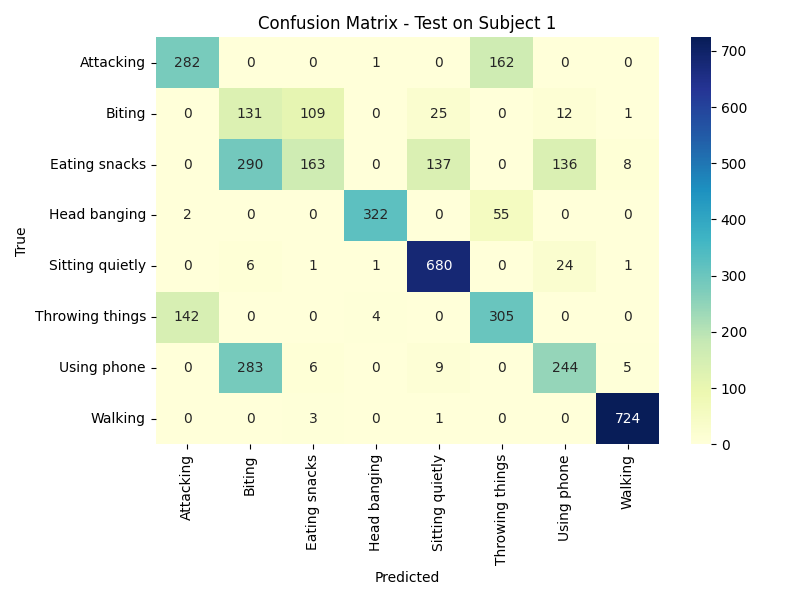


📄 Classification Report:
                 precision    recall  f1-score   support

      Attacking       0.66      0.63      0.65       445
         Biting       0.18      0.47      0.27       278
  Eating snacks       0.58      0.22      0.32       734
   Head banging       0.98      0.85      0.91       379
Sitting quietly       0.80      0.95      0.87       713
Throwing things       0.58      0.68      0.63       451
    Using phone       0.59      0.45      0.51       547
        Walking       0.98      0.99      0.99       728

       accuracy                           0.67      4275
      macro avg       0.67      0.66      0.64      4275
   weighted avg       0.70      0.67      0.66      4275

✅ Epoch 1: 🔥 New best model saved with F1: 0.4670
✅ Epoch 2: 🔥 New best model saved with F1: 0.4987
✅ Epoch 3: 🔥 New best model saved with F1: 0.5132
✅ Epoch 4: 🔥 New best model saved with F1: 0.5162
✅ Epoch 5: 🔥 New best model saved with F1: 0.5220
✅ Epoch 7: 🔥 New best model saved wit

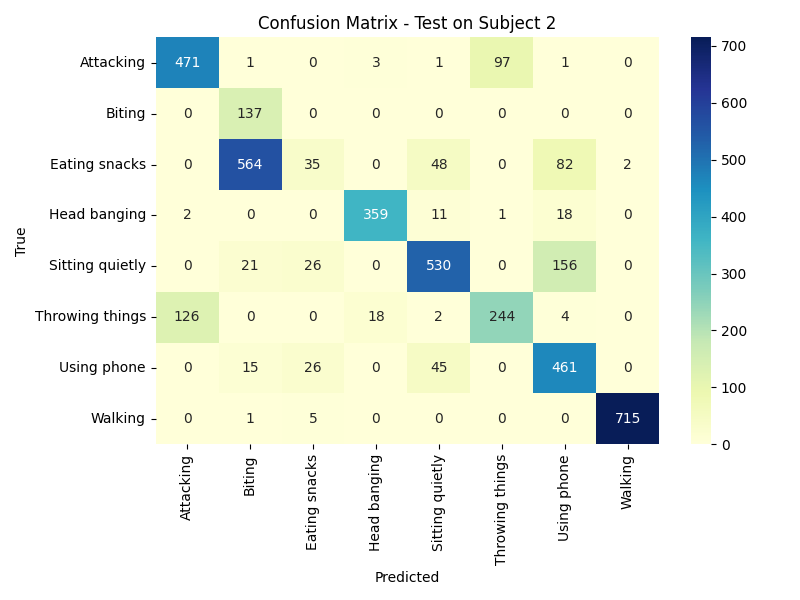


📄 Classification Report:
                 precision    recall  f1-score   support

      Attacking       0.79      0.82      0.80       574
         Biting       0.19      1.00      0.31       137
  Eating snacks       0.38      0.05      0.09       731
   Head banging       0.94      0.92      0.93       391
Sitting quietly       0.83      0.72      0.77       733
Throwing things       0.71      0.62      0.66       394
    Using phone       0.64      0.84      0.73       547
        Walking       1.00      0.99      0.99       721

       accuracy                           0.70      4228
      macro avg       0.68      0.75      0.66      4228
   weighted avg       0.73      0.70      0.68      4228

✅ Epoch 1: 🔥 New best model saved with F1: 0.5363
✅ Epoch 2: 🔥 New best model saved with F1: 0.5574
✅ Epoch 3: 🔥 New best model saved with F1: 0.5779
✅ Epoch 5: 🔥 New best model saved with F1: 0.5851
✅ Epoch 8: 🔥 New best model saved with F1: 0.5881
✅ Epoch 10: 🔥 New best model saved wi

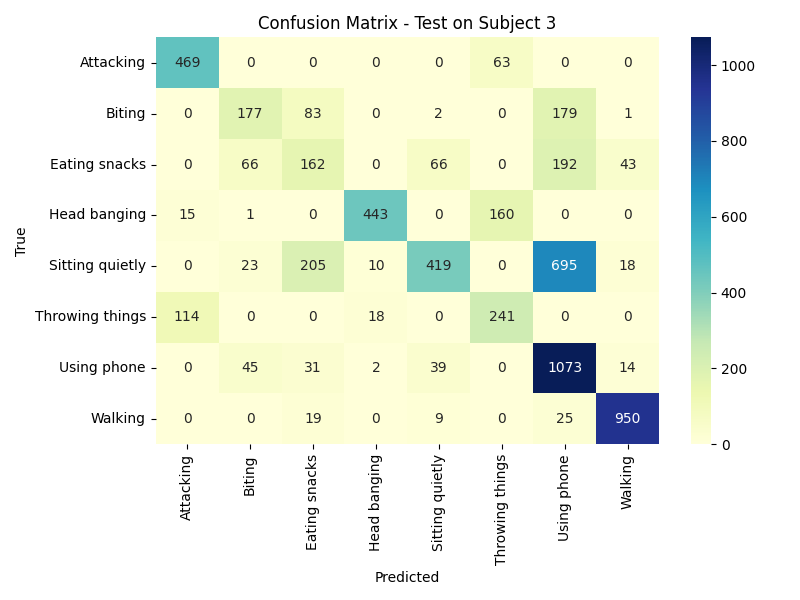


📄 Classification Report:
                 precision    recall  f1-score   support

      Attacking       0.78      0.88      0.83       532
         Biting       0.57      0.40      0.47       442
  Eating snacks       0.32      0.31      0.31       529
   Head banging       0.94      0.72      0.81       619
Sitting quietly       0.78      0.31      0.44      1370
Throwing things       0.52      0.65      0.58       373
    Using phone       0.50      0.89      0.64      1204
        Walking       0.93      0.95      0.94      1003

       accuracy                           0.65      6072
      macro avg       0.67      0.64      0.63      6072
   weighted avg       0.69      0.65      0.63      6072

✅ Epoch 1: 🔥 New best model saved with F1: 0.6839
✅ Epoch 2: 🔥 New best model saved with F1: 0.7346
✅ Epoch 3: 🔥 New best model saved with F1: 0.7846
✅ Epoch 6: 🔥 New best model saved with F1: 0.8122
✅ Epoch 30: 🔥 New best model saved with F1: 0.8124
✅ Epoch 118: 🔥 New best model saved 

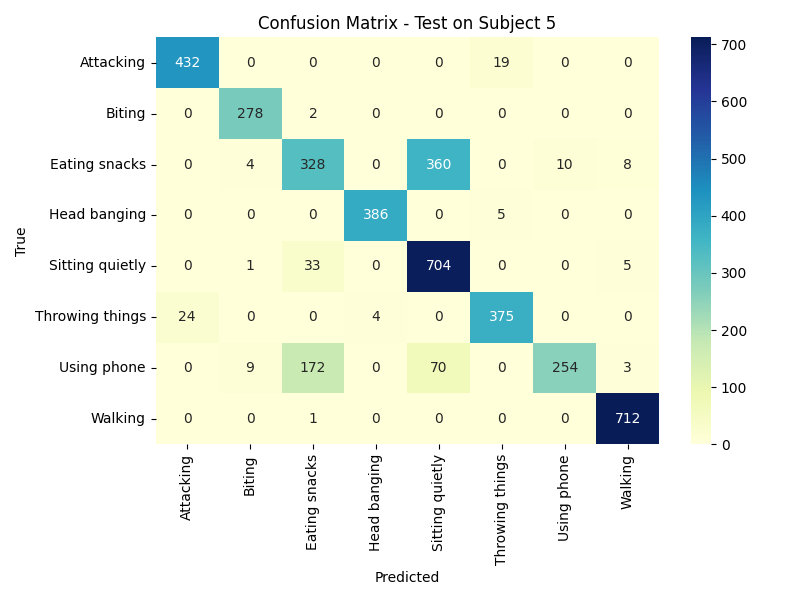


📄 Classification Report:
                 precision    recall  f1-score   support

      Attacking       0.95      0.96      0.95       451
         Biting       0.95      0.99      0.97       280
  Eating snacks       0.61      0.46      0.53       710
   Head banging       0.99      0.99      0.99       391
Sitting quietly       0.62      0.95      0.75       743
Throwing things       0.94      0.93      0.94       403
    Using phone       0.96      0.50      0.66       508
        Walking       0.98      1.00      0.99       713

       accuracy                           0.83      4199
      macro avg       0.88      0.85      0.85      4199
   weighted avg       0.84      0.83      0.82      4199


📊 === KẾT QUẢ TRUNG BÌNH LOSO (MLP) ===
Accuracy  : 0.7098
Precision : 0.7425
Recall    : 0.7098
F1        : 0.6987
Log_loss  : 1.0747


In [25]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, log_loss, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils.class_weight import compute_class_weight
# ==== CONFIG ====
subject_ids = [1, 2, 3, 5]
data_dir = "features"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_dim = 20
hidden_dim = 64
num_epochs = 200
batch_size = 32
lr = 1e-3

# ==== MLP Model ====
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes):
        super(MLP, self).__init__()
        self.model = nn.Sequential(
      nn.Linear(input_dim, hidden_dim),
      nn.BatchNorm1d(hidden_dim),
      nn.ReLU(),
      nn.Dropout(0.3),
      nn.Linear(hidden_dim, hidden_dim),
      nn.BatchNorm1d(hidden_dim),
      nn.ReLU(),
      nn.Dropout(0.3),
      nn.Linear(hidden_dim, num_classes)
  )

    def forward(self, x):
        return self.model(x)

# ==== Training function ====
def train_model(model, train_loader, criterion, optimizer):
    model.train()
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

# ==== Evaluation function ====
def evaluate_model(model, X_test, y_test):
    model.eval()
    with torch.no_grad():
        X_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
        outputs = model(X_tensor)
        y_pred = outputs.argmax(dim=1).cpu().numpy()
        y_proba = torch.softmax(outputs, dim=1).cpu().numpy()
    return y_pred, y_proba

# ==== LOSO Training ====
all_metrics = {"accuracy": [], "precision": [], "recall": [], "f1": [], "log_loss": []}

for test_id in subject_ids:
    # Load data
    df_test = pd.read_csv(f"{data_dir}/cleaned_keypoints_with_labels_{test_id}_features.csv")
    df_train = pd.concat([
        pd.read_csv(f"{data_dir}/cleaned_keypoints_with_labels_{i}_features.csv")
        for i in subject_ids if i != test_id
    ], ignore_index=True)

    X_train, y_train = df_train.drop(columns=["action"]), df_train["action"]
    X_test, y_test = df_test.drop(columns=["action"]), df_test["action"]

    # Encode label
    le = LabelEncoder()
    y_train_enc = le.fit_transform(y_train)
    y_test_enc = le.transform(y_test)

    # Impute missing values
    imputer = SimpleImputer(strategy='mean')
    X_train = imputer.fit_transform(X_train)
    X_test = imputer.transform(X_test)

    # Standardize
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    num_classes = len(le.classes_)

    # PyTorch DataLoader
    train_dataset = torch.utils.data.TensorDataset(
        torch.tensor(X_train, dtype=torch.float32),
        torch.tensor(y_train_enc, dtype=torch.long)
    )
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    # Model init
    model = MLP(input_dim=input_dim, hidden_dim=hidden_dim, num_classes=num_classes).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    weights = compute_class_weight('balanced', classes=np.unique(y_train_enc), y=y_train_enc)
    criterion = nn.CrossEntropyLoss(weight=torch.tensor(weights, dtype=torch.float32).to(device))

    # Train
    best_model_path = f"best_model_subject_{test_id}.pt"
    best_f1 = 0.0

    for epoch in range(num_epochs):
        train_model(model, train_loader, criterion, optimizer)

        # Evaluate mỗi epoch trên tập test
        y_pred_epoch, _ = evaluate_model(model, X_test, y_test_enc)
        f1_epoch = f1_score(y_test_enc, y_pred_epoch, average='weighted', zero_division=0)

        # Lưu nếu tốt hơn
        if f1_epoch > best_f1:
            best_f1 = f1_epoch
            torch.save(model.state_dict(), best_model_path)
            print(f"✅ Epoch {epoch+1}: 🔥 New best model saved with F1: {f1_epoch:.4f}")
    model.load_state_dict(torch.load(best_model_path))
    # Predict
    y_pred, y_proba = evaluate_model(model, X_test, y_test_enc)

    # Metrics
    acc = accuracy_score(y_test_enc, y_pred)
    prec = precision_score(y_test_enc, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test_enc, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test_enc, y_pred, average='weighted', zero_division=0)
    loss = log_loss(y_test_enc, y_proba)

    print(f"\n📂 Fold: Train on [{', '.join(str(i) for i in subject_ids if i != test_id)}], Test on [{test_id}]")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall   : {rec:.4f}")
    print(f"  F1 Score : {f1:.4f}")
    print(f"  Log Loss : {loss:.4f}")

    all_metrics["accuracy"].append(acc)
    all_metrics["precision"].append(prec)
    all_metrics["recall"].append(rec)
    all_metrics["f1"].append(f1)
    all_metrics["log_loss"].append(loss)

    # Confusion Matrix
    cm = confusion_matrix(y_test_enc, y_pred)
    cm_df = pd.DataFrame(cm, index=le.classes_, columns=le.classes_)
    print("\n🧩 Confusion Matrix:")
    print(cm_df)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_df, annot=True, fmt='d', cmap='YlGnBu')
    plt.title(f'Confusion Matrix - Test on Subject {test_id}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.show()

    print("\n📄 Classification Report:")
    print(classification_report(y_test_enc, y_pred, target_names=le.classes_))

# Tổng kết
print("\n📊 === KẾT QUẢ TRUNG BÌNH LOSO (MLP) ===")
for metric in all_metrics:
    print(f"{metric.capitalize():<10}: {np.mean(all_metrics[metric]):.4f}")


## LSTM

✅ Epoch 1: 🔥 New best model saved with F1: 0.3620
✅ Epoch 2: 🔥 New best model saved with F1: 0.4746
✅ Epoch 3: 🔥 New best model saved with F1: 0.4992
✅ Epoch 4: 🔥 New best model saved with F1: 0.5548
✅ Epoch 5: 🔥 New best model saved with F1: 0.6169
✅ Epoch 7: 🔥 New best model saved with F1: 0.6235
✅ Epoch 8: 🔥 New best model saved with F1: 0.6733
✅ Epoch 9: 🔥 New best model saved with F1: 0.6828
✅ Epoch 10: 🔥 New best model saved with F1: 0.6901
✅ Epoch 12: 🔥 New best model saved with F1: 0.6950
✅ Epoch 13: 🔥 New best model saved with F1: 0.6966
✅ Epoch 14: 🔥 New best model saved with F1: 0.6970

📂 Fold: Train on [2, 3, 5], Test on [1]
  Accuracy : 0.7200
  Precision: 0.7283
  Recall   : 0.7200
  F1 Score : 0.6970
  Log Loss : 0.8897

🧩 Confusion Matrix:
                 Attacking  Biting  Eating snacks  Head banging  \
Attacking              302       1              9             5   
Biting                  73     151             33             0   
Eating snacks           20     11

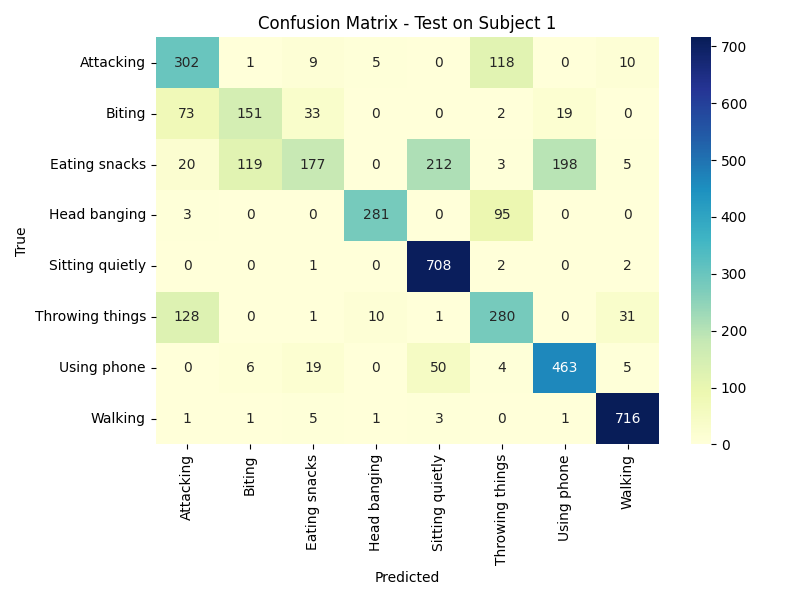


📄 Classification Report:
                 precision    recall  f1-score   support

      Attacking       0.57      0.68      0.62       445
         Biting       0.54      0.54      0.54       278
  Eating snacks       0.72      0.24      0.36       734
   Head banging       0.95      0.74      0.83       379
Sitting quietly       0.73      0.99      0.84       713
Throwing things       0.56      0.62      0.59       451
    Using phone       0.68      0.85      0.75       547
        Walking       0.93      0.98      0.96       728

       accuracy                           0.72      4275
      macro avg       0.71      0.71      0.69      4275
   weighted avg       0.73      0.72      0.70      4275

✅ Epoch 1: 🔥 New best model saved with F1: 0.2708
✅ Epoch 2: 🔥 New best model saved with F1: 0.2923
✅ Epoch 3: 🔥 New best model saved with F1: 0.3317
✅ Epoch 4: 🔥 New best model saved with F1: 0.3613
✅ Epoch 5: 🔥 New best model saved with F1: 0.3776
✅ Epoch 6: 🔥 New best model saved wit

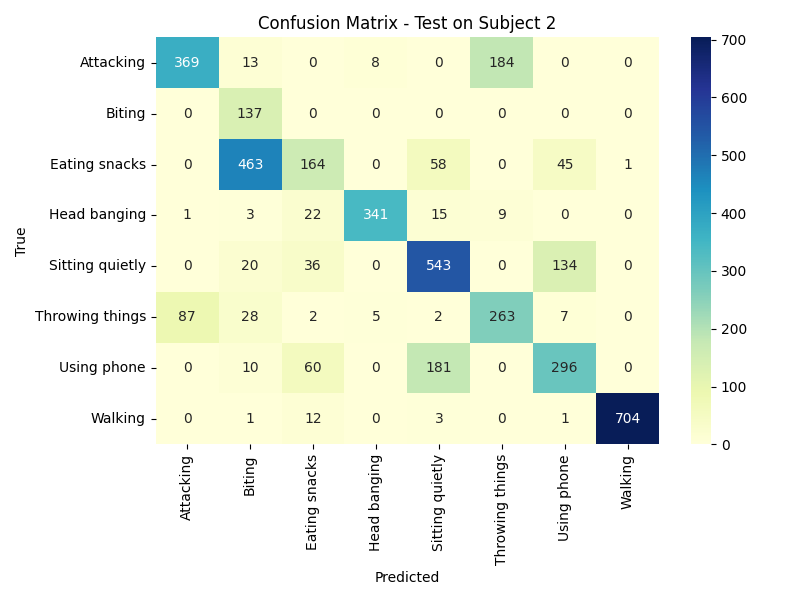


📄 Classification Report:
                 precision    recall  f1-score   support

      Attacking       0.81      0.64      0.72       574
         Biting       0.20      1.00      0.34       137
  Eating snacks       0.55      0.22      0.32       731
   Head banging       0.96      0.87      0.92       391
Sitting quietly       0.68      0.74      0.71       733
Throwing things       0.58      0.67      0.62       394
    Using phone       0.61      0.54      0.57       547
        Walking       1.00      0.98      0.99       721

       accuracy                           0.67      4228
      macro avg       0.67      0.71      0.65      4228
   weighted avg       0.72      0.67      0.67      4228

✅ Epoch 1: 🔥 New best model saved with F1: 0.3516
✅ Epoch 2: 🔥 New best model saved with F1: 0.3724
✅ Epoch 3: 🔥 New best model saved with F1: 0.4997
✅ Epoch 11: 🔥 New best model saved with F1: 0.5081
✅ Epoch 12: 🔥 New best model saved with F1: 0.5168
✅ Epoch 14: 🔥 New best model saved 

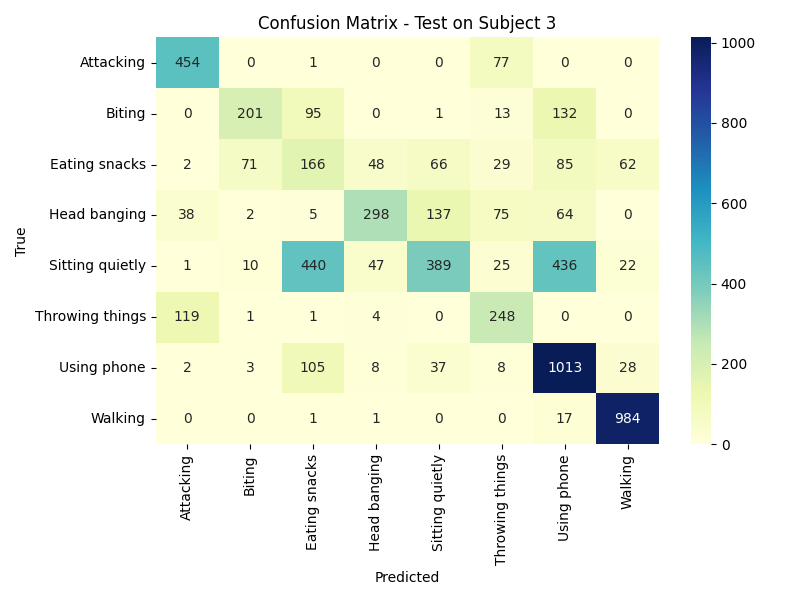


📄 Classification Report:
                 precision    recall  f1-score   support

      Attacking       0.74      0.85      0.79       532
         Biting       0.70      0.45      0.55       442
  Eating snacks       0.20      0.31      0.25       529
   Head banging       0.73      0.48      0.58       619
Sitting quietly       0.62      0.28      0.39      1370
Throwing things       0.52      0.66      0.58       373
    Using phone       0.58      0.84      0.69      1204
        Walking       0.90      0.98      0.94      1003

       accuracy                           0.62      6072
      macro avg       0.62      0.61      0.60      6072
   weighted avg       0.64      0.62      0.60      6072

✅ Epoch 1: 🔥 New best model saved with F1: 0.4537
✅ Epoch 2: 🔥 New best model saved with F1: 0.4987
✅ Epoch 3: 🔥 New best model saved with F1: 0.4988
✅ Epoch 5: 🔥 New best model saved with F1: 0.5025
✅ Epoch 6: 🔥 New best model saved with F1: 0.5036
✅ Epoch 7: 🔥 New best model saved wit

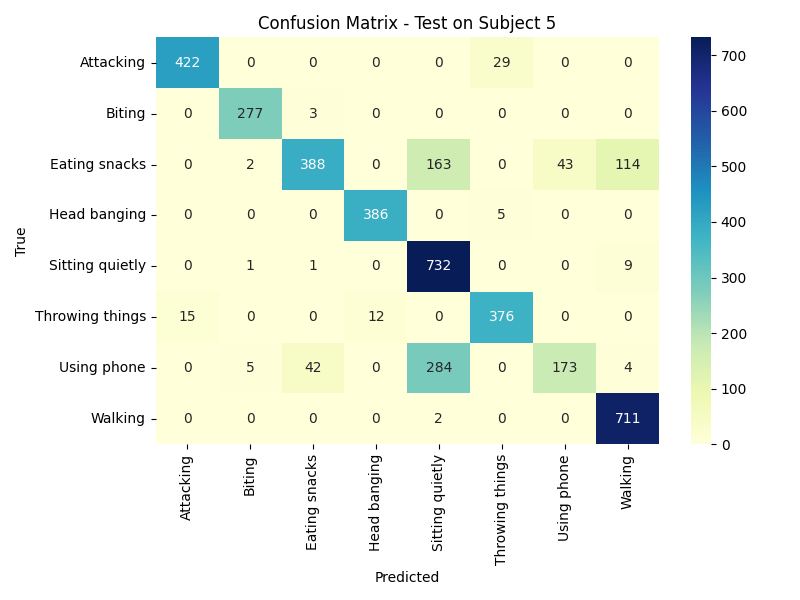


📄 Classification Report:
                 precision    recall  f1-score   support

      Attacking       0.97      0.94      0.95       451
         Biting       0.97      0.99      0.98       280
  Eating snacks       0.89      0.55      0.68       710
   Head banging       0.97      0.99      0.98       391
Sitting quietly       0.62      0.99      0.76       743
Throwing things       0.92      0.93      0.92       403
    Using phone       0.80      0.34      0.48       508
        Walking       0.85      1.00      0.92       713

       accuracy                           0.83      4199
      macro avg       0.87      0.84      0.83      4199
   weighted avg       0.85      0.83      0.81      4199


📊 === KẾT QUẢ TRUNG BÌNH LOSO (LSTM) ===
Accuracy  : 0.7074
Precision : 0.7353
Recall    : 0.7074
F1        : 0.6958
Log_loss  : 1.0220


In [26]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, log_loss, classification_report, confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils.class_weight import compute_class_weight

# ==== CONFIG ====
subject_ids = [1, 2, 3, 5]
data_dir = "features"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_dim = 20
hidden_dim = 64
num_epochs = 200
batch_size = 32
lr = 1e-4

# ==== LSTM Model ====
class LSTMClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes, num_layers=1, bidirectional=False):
        super(LSTMClassifier, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=bidirectional
        )
        self.fc = nn.Linear(
            hidden_dim * (2 if bidirectional else 1),
            num_classes
        )

    def forward(self, x):
        # x: (batch, seq_len, input_dim)
        lstm_out, _ = self.lstm(x)
        last_hidden = lstm_out[:, -1, :]  # lấy hidden cuối
        out = self.fc(last_hidden)
        return out

# ==== Training function ====
def train_model(model, train_loader, criterion, optimizer):
    model.train()
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

# ==== Evaluation function ====
def evaluate_model(model, X_test, y_test):
    model.eval()
    with torch.no_grad():
        X_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
        outputs = model(X_tensor)
        y_pred = outputs.argmax(dim=1).cpu().numpy()
        y_proba = torch.softmax(outputs, dim=1).cpu().numpy()
    return y_pred, y_proba

# ==== LOSO Training ====
all_metrics = {"accuracy": [], "precision": [], "recall": [], "f1": [], "log_loss": []}

for test_id in subject_ids:
    # Load data
    df_test = pd.read_csv(f"{data_dir}/cleaned_keypoints_with_labels_{test_id}_features.csv")
    df_train = pd.concat([
        pd.read_csv(f"{data_dir}/cleaned_keypoints_with_labels_{i}_features.csv")
        for i in subject_ids if i != test_id
    ], ignore_index=True)

    X_train, y_train = df_train.drop(columns=["action"]), df_train["action"]
    X_test, y_test = df_test.drop(columns=["action"]), df_test["action"]

    # Encode label
    le = LabelEncoder()
    y_train_enc = le.fit_transform(y_train)
    y_test_enc = le.transform(y_test)

    # Impute missing values
    imputer = SimpleImputer(strategy='mean')
    X_train = imputer.fit_transform(X_train)
    X_test = imputer.transform(X_test)

    # Standardize
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    num_classes = len(le.classes_)

    # Reshape for LSTM: (N, seq_len=1, input_dim)
    X_train = X_train.reshape(-1, 1, input_dim)
    X_test = X_test.reshape(-1, 1, input_dim)

    # PyTorch DataLoader
    train_dataset = torch.utils.data.TensorDataset(
        torch.tensor(X_train, dtype=torch.float32),
        torch.tensor(y_train_enc, dtype=torch.long)
    )
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    # Model init
    model = LSTMClassifier(
        input_dim=input_dim,
        hidden_dim=hidden_dim,
        num_classes=num_classes,
        num_layers=1,
        bidirectional=False
    ).to(device)

    optimizer = optim.Adam(model.parameters(), lr=lr)
    weights = compute_class_weight('balanced', classes=np.unique(y_train_enc), y=y_train_enc)
    criterion = nn.CrossEntropyLoss(weight=torch.tensor(weights, dtype=torch.float32).to(device))

    # Train
    best_model_path = f"best_model_subject_{test_id}.pt"
    best_f1 = 0.0

    for epoch in range(num_epochs):
        train_model(model, train_loader, criterion, optimizer)

        # Evaluate mỗi epoch trên tập test
        y_pred_epoch, _ = evaluate_model(model, X_test, y_test_enc)
        f1_epoch = f1_score(y_test_enc, y_pred_epoch, average='weighted', zero_division=0)

        # Lưu nếu tốt hơn
        if f1_epoch > best_f1:
            best_f1 = f1_epoch
            torch.save(model.state_dict(), best_model_path)
            print(f"✅ Epoch {epoch+1}: 🔥 New best model saved with F1: {f1_epoch:.4f}")

    model.load_state_dict(torch.load(best_model_path))

    # Predict
    y_pred, y_proba = evaluate_model(model, X_test, y_test_enc)

    # Metrics
    acc = accuracy_score(y_test_enc, y_pred)
    prec = precision_score(y_test_enc, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test_enc, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test_enc, y_pred, average='weighted', zero_division=0)
    loss = log_loss(y_test_enc, y_proba)

    print(f"\n📂 Fold: Train on [{', '.join(str(i) for i in subject_ids if i != test_id)}], Test on [{test_id}]")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall   : {rec:.4f}")
    print(f"  F1 Score : {f1:.4f}")
    print(f"  Log Loss : {loss:.4f}")

    all_metrics["accuracy"].append(acc)
    all_metrics["precision"].append(prec)
    all_metrics["recall"].append(rec)
    all_metrics["f1"].append(f1)
    all_metrics["log_loss"].append(loss)

    # Confusion Matrix
    cm = confusion_matrix(y_test_enc, y_pred)
    cm_df = pd.DataFrame(cm, index=le.classes_, columns=le.classes_)
    print("\n🧩 Confusion Matrix:")
    print(cm_df)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_df, annot=True, fmt='d', cmap='YlGnBu')
    plt.title(f'Confusion Matrix - Test on Subject {test_id}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.show()

    print("\n📄 Classification Report:")
    print(classification_report(y_test_enc, y_pred, target_names=le.classes_))

# Tổng kết
print("\n📊 === KẾT QUẢ TRUNG BÌNH LOSO (LSTM) ===")
for metric in all_metrics:
    print(f"{metric.capitalize():<10}: {np.mean(all_metrics[metric]):.4f}")


# LSTM + Sliding Window

📋 Fold 1: X_train shape = (1430, 30, 20), X_test shape = (407, 30, 20)
✅ Epoch 1: 🔥 New best model saved with F1: 0.1853
✅ Epoch 2: 🔥 New best model saved with F1: 0.2172
✅ Epoch 3: 🔥 New best model saved with F1: 0.2426
✅ Epoch 4: 🔥 New best model saved with F1: 0.2661
✅ Epoch 5: 🔥 New best model saved with F1: 0.3001
✅ Epoch 6: 🔥 New best model saved with F1: 0.3908
✅ Epoch 7: 🔥 New best model saved with F1: 0.4890
✅ Epoch 13: 🔥 New best model saved with F1: 0.4893
✅ Epoch 16: 🔥 New best model saved with F1: 0.5172
✅ Epoch 18: 🔥 New best model saved with F1: 0.5246
✅ Epoch 19: 🔥 New best model saved with F1: 0.5333
✅ Epoch 38: 🔥 New best model saved with F1: 0.5635
✅ Epoch 39: 🔥 New best model saved with F1: 0.5683
✅ Epoch 40: 🔥 New best model saved with F1: 0.5904
✅ Epoch 42: 🔥 New best model saved with F1: 0.6166
✅ Epoch 133: 🔥 New best model saved with F1: 0.6429
✅ Epoch 135: 🔥 New best model saved with F1: 0.6429
✅ Epoch 137: 🔥 New best model saved with F1: 0.6481
✅ Epoch 141: 🔥 

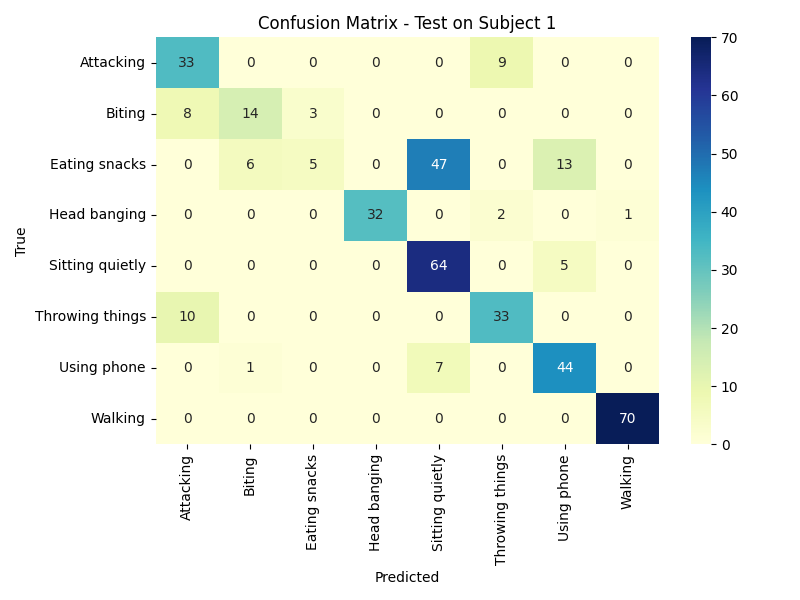


📄 Classification Report:
                 precision    recall  f1-score   support

      Attacking       0.65      0.79      0.71        42
         Biting       0.67      0.56      0.61        25
  Eating snacks       0.62      0.07      0.13        71
   Head banging       1.00      0.91      0.96        35
Sitting quietly       0.54      0.93      0.68        69
Throwing things       0.75      0.77      0.76        43
    Using phone       0.71      0.85      0.77        52
        Walking       0.99      1.00      0.99        70

       accuracy                           0.72       407
      macro avg       0.74      0.73      0.70       407
   weighted avg       0.73      0.72      0.68       407

📋 Fold 2: X_train shape = (1434, 30, 20), X_test shape = (404, 30, 20)
✅ Epoch 1: 🔥 New best model saved with F1: 0.1806
✅ Epoch 2: 🔥 New best model saved with F1: 0.1929
✅ Epoch 5: 🔥 New best model saved with F1: 0.1998
✅ Epoch 6: 🔥 New best model saved with F1: 0.2120
✅ Epoch 7: 🔥 New

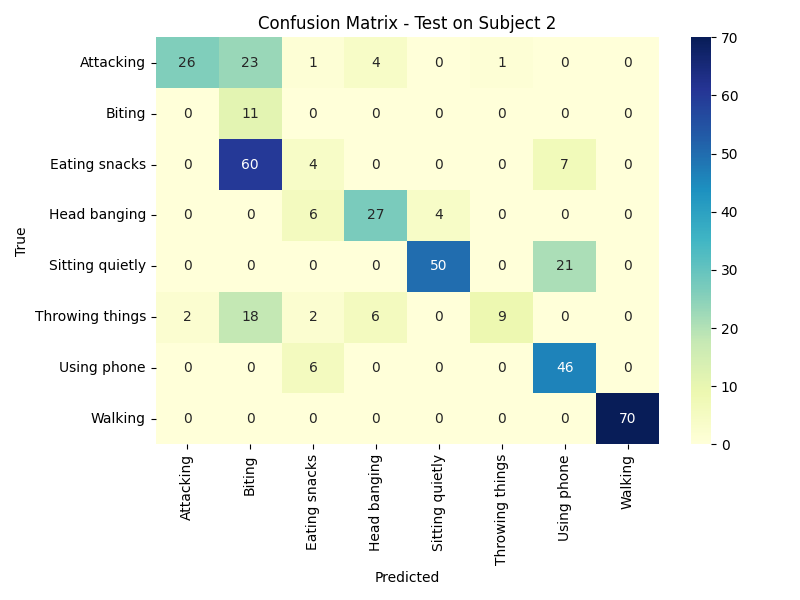


📄 Classification Report:
                 precision    recall  f1-score   support

      Attacking       0.93      0.47      0.63        55
         Biting       0.10      1.00      0.18        11
  Eating snacks       0.21      0.06      0.09        71
   Head banging       0.73      0.73      0.73        37
Sitting quietly       0.93      0.70      0.80        71
Throwing things       0.90      0.24      0.38        37
    Using phone       0.62      0.88      0.73        52
        Walking       1.00      1.00      1.00        70

       accuracy                           0.60       404
      macro avg       0.68      0.64      0.57       404
   weighted avg       0.73      0.60      0.62       404

📋 Fold 3: X_train shape = (1251, 30, 20), X_test shape = (588, 30, 20)
✅ Epoch 1: 🔥 New best model saved with F1: 0.2033
✅ Epoch 2: 🔥 New best model saved with F1: 0.2197
✅ Epoch 3: 🔥 New best model saved with F1: 0.2667
✅ Epoch 4: 🔥 New best model saved with F1: 0.3535
✅ Epoch 5: 🔥 New

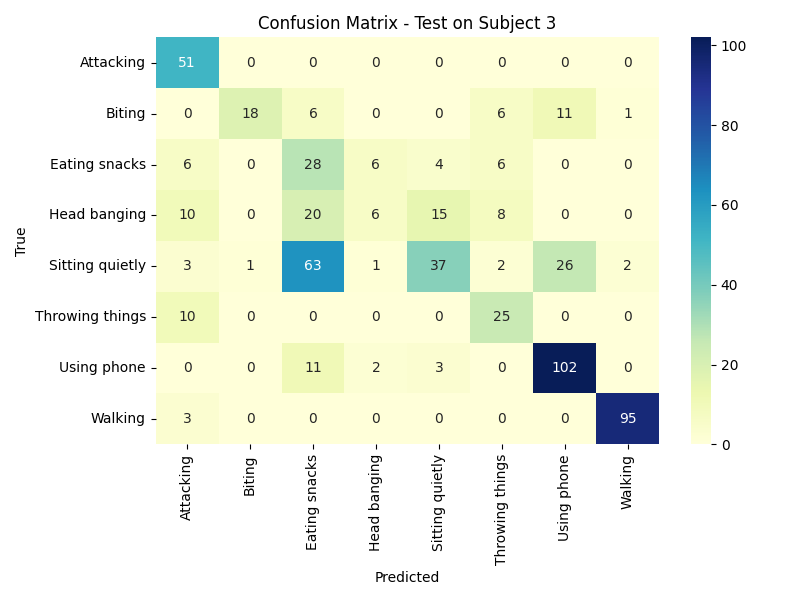


📄 Classification Report:
                 precision    recall  f1-score   support

      Attacking       0.61      1.00      0.76        51
         Biting       0.95      0.43      0.59        42
  Eating snacks       0.22      0.56      0.31        50
   Head banging       0.40      0.10      0.16        59
Sitting quietly       0.63      0.27      0.38       135
Throwing things       0.53      0.71      0.61        35
    Using phone       0.73      0.86      0.79       118
        Walking       0.97      0.97      0.97        98

       accuracy                           0.62       588
      macro avg       0.63      0.61      0.57       588
   weighted avg       0.66      0.62      0.60       588

📋 Fold 5: X_train shape = (1437, 30, 20), X_test shape = (402, 30, 20)
✅ Epoch 1: 🔥 New best model saved with F1: 0.2527
✅ Epoch 2: 🔥 New best model saved with F1: 0.3511
✅ Epoch 3: 🔥 New best model saved with F1: 0.4784
✅ Epoch 4: 🔥 New best model saved with F1: 0.5678
✅ Epoch 5: 🔥 New

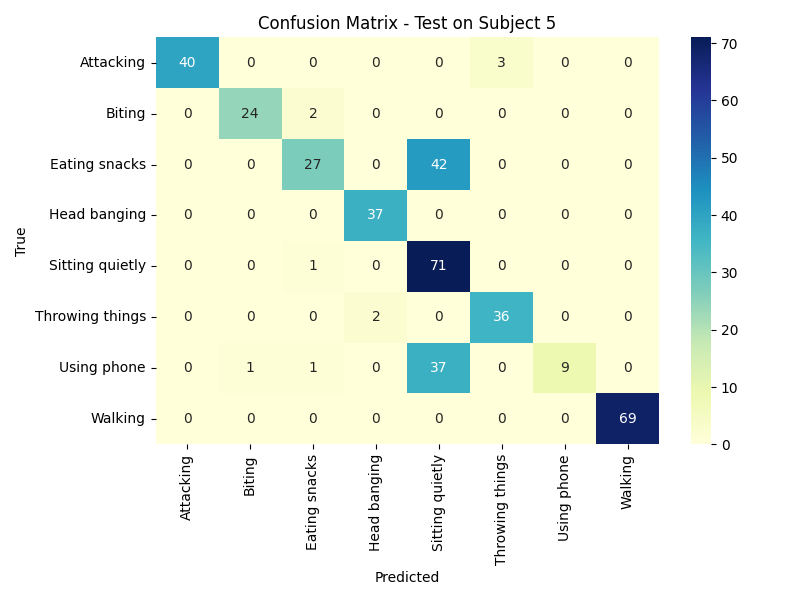


📄 Classification Report:
                 precision    recall  f1-score   support

      Attacking       1.00      0.93      0.96        43
         Biting       0.96      0.92      0.94        26
  Eating snacks       0.87      0.39      0.54        69
   Head banging       0.95      1.00      0.97        37
Sitting quietly       0.47      0.99      0.64        72
Throwing things       0.92      0.95      0.94        38
    Using phone       1.00      0.19      0.32        48
        Walking       1.00      1.00      1.00        69

       accuracy                           0.78       402
      macro avg       0.90      0.80      0.79       402
   weighted avg       0.87      0.78      0.76       402


📊 === KẾT QUẢ TRUNG BÌNH LOSO (LSTM + Sliding) ===
Accuracy  : 0.6801
Precision : 0.7497
Recall    : 0.6801
F1        : 0.6626
Log_loss  : 1.4844


In [27]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, log_loss, classification_report, confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils.class_weight import compute_class_weight

# ==== CONFIG ====
subject_ids = [1, 2, 3, 5]
data_dir = "features"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_dim = 20
hidden_dim = 64
num_epochs = 200
batch_size = 32
lr = 1e-4
seq_len = 30
step_size = 10

# ==== LSTM Model ====
class LSTMClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes, num_layers=1, bidirectional=False):
        super(LSTMClassifier, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=bidirectional
        )
        self.fc = nn.Linear(
            hidden_dim * (2 if bidirectional else 1),
            num_classes
        )

    def forward(self, x):
        # x: (batch, seq_len, input_dim)
        lstm_out, _ = self.lstm(x)
        last_hidden = lstm_out[:, -1, :]  # lấy hidden cuối
        out = self.fc(last_hidden)
        return out

# ==== Sliding window ====
def create_sliding_windows(X, y, seq_len, step_size):
    X_seq, y_seq = [], []
    for label in np.unique(y):
        idx = np.where(y == label)[0]
        X_label = X[idx]
        y_label = y[idx]
        for i in range(0, len(X_label) - seq_len + 1, step_size):
            X_seq.append(X_label[i:i+seq_len])
            y_seq.append(y_label[i+seq_len-1])  # nhãn frame cuối
    return np.array(X_seq), np.array(y_seq)

# ==== Training function ====
def train_model(model, train_loader, criterion, optimizer):
    model.train()
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

# ==== Evaluation function ====
def evaluate_model(model, X_test, y_test):
    model.eval()
    with torch.no_grad():
        X_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
        outputs = model(X_tensor)
        y_pred = outputs.argmax(dim=1).cpu().numpy()
        y_proba = torch.softmax(outputs, dim=1).cpu().numpy()
    return y_pred, y_proba

# ==== LOSO Training ====
all_metrics = {"accuracy": [], "precision": [], "recall": [], "f1": [], "log_loss": []}

for test_id in subject_ids:
    # Load data
    df_test = pd.read_csv(f"{data_dir}/cleaned_keypoints_with_labels_{test_id}_features.csv")
    df_train = pd.concat([
        pd.read_csv(f"{data_dir}/cleaned_keypoints_with_labels_{i}_features.csv")
        for i in subject_ids if i != test_id
    ], ignore_index=True)

    X_train, y_train = df_train.drop(columns=["action"]), df_train["action"]
    X_test, y_test = df_test.drop(columns=["action"]), df_test["action"]

    # Encode label
    le = LabelEncoder()
    y_train_enc = le.fit_transform(y_train)
    y_test_enc = le.transform(y_test)

    # Impute missing values
    imputer = SimpleImputer(strategy='mean')
    X_train = imputer.fit_transform(X_train)
    X_test = imputer.transform(X_test)

    # Standardize
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    num_classes = len(le.classes_)

    # Sliding window
    X_train, y_train_enc = create_sliding_windows(X_train, y_train_enc, seq_len, step_size)
    X_test, y_test_enc = create_sliding_windows(X_test, y_test_enc, seq_len, step_size)

    print(f"📋 Fold {test_id}: X_train shape = {X_train.shape}, X_test shape = {X_test.shape}")

    # PyTorch DataLoader
    train_dataset = torch.utils.data.TensorDataset(
        torch.tensor(X_train, dtype=torch.float32),
        torch.tensor(y_train_enc, dtype=torch.long)
    )
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    # Model init
    model = LSTMClassifier(
        input_dim=input_dim,
        hidden_dim=hidden_dim,
        num_classes=num_classes,
        num_layers=1,
        bidirectional=False
    ).to(device)

    optimizer = optim.Adam(model.parameters(), lr=lr)
    weights = compute_class_weight('balanced', classes=np.unique(y_train_enc), y=y_train_enc)
    criterion = nn.CrossEntropyLoss(weight=torch.tensor(weights, dtype=torch.float32).to(device))

    # Train
    best_model_path = f"best_model_subject_{test_id}.pt"
    best_f1 = 0.0

    for epoch in range(num_epochs):
        train_model(model, train_loader, criterion, optimizer)

        # Evaluate mỗi epoch trên tập test
        y_pred_epoch, _ = evaluate_model(model, X_test, y_test_enc)
        f1_epoch = f1_score(y_test_enc, y_pred_epoch, average='weighted', zero_division=0)

        # Lưu nếu tốt hơn
        if f1_epoch > best_f1:
            best_f1 = f1_epoch
            torch.save(model.state_dict(), best_model_path)
            print(f"✅ Epoch {epoch+1}: 🔥 New best model saved with F1: {f1_epoch:.4f}")

    model.load_state_dict(torch.load(best_model_path))

    # Predict
    y_pred, y_proba = evaluate_model(model, X_test, y_test_enc)

    # Metrics
    acc = accuracy_score(y_test_enc, y_pred)
    prec = precision_score(y_test_enc, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test_enc, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test_enc, y_pred, average='weighted', zero_division=0)
    loss = log_loss(y_test_enc, y_proba)

    print(f"\n📂 Fold: Train on [{', '.join(str(i) for i in subject_ids if i != test_id)}], Test on [{test_id}]")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall   : {rec:.4f}")
    print(f"  F1 Score : {f1:.4f}")
    print(f"  Log Loss : {loss:.4f}")

    all_metrics["accuracy"].append(acc)
    all_metrics["precision"].append(prec)
    all_metrics["recall"].append(rec)
    all_metrics["f1"].append(f1)
    all_metrics["log_loss"].append(loss)

    # Confusion Matrix
    cm = confusion_matrix(y_test_enc, y_pred)
    cm_df = pd.DataFrame(cm, index=le.classes_, columns=le.classes_)
    print("\n🧩 Confusion Matrix:")
    print(cm_df)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_df, annot=True, fmt='d', cmap='YlGnBu')
    plt.title(f'Confusion Matrix - Test on Subject {test_id}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.show()

    print("\n📄 Classification Report:")
    print(classification_report(y_test_enc, y_pred, target_names=le.classes_))

# Tổng kết
print("\n📊 === KẾT QUẢ TRUNG BÌNH LOSO (LSTM + Sliding) ===")
for metric in all_metrics:
    print(f"{metric.capitalize():<10}: {np.mean(all_metrics[metric]):.4f}")


## LSTM ver 2

📋 Fold 1: X_train shape = (1430, 30, 20), X_test shape = (407, 30, 20)
✅ Epoch 1: 🔥 New best model saved with F1: 0.2637
✅ Epoch 2: 🔥 New best model saved with F1: 0.3057
✅ Epoch 3: 🔥 New best model saved with F1: 0.4372
EarlyStopping counter: 1/20
✅ Epoch 5: 🔥 New best model saved with F1: 0.5669
EarlyStopping counter: 1/20
EarlyStopping counter: 2/20
EarlyStopping counter: 3/20
EarlyStopping counter: 4/20
EarlyStopping counter: 5/20
EarlyStopping counter: 6/20
EarlyStopping counter: 7/20
✅ Epoch 13: 🔥 New best model saved with F1: 0.5935
✅ Epoch 14: 🔥 New best model saved with F1: 0.6002
✅ Epoch 15: 🔥 New best model saved with F1: 0.6020
✅ Epoch 16: 🔥 New best model saved with F1: 0.6204
✅ Epoch 17: 🔥 New best model saved with F1: 0.6575
EarlyStopping counter: 1/20
EarlyStopping counter: 2/20
EarlyStopping counter: 3/20
✅ Epoch 21: 🔥 New best model saved with F1: 0.6778
EarlyStopping counter: 1/20
EarlyStopping counter: 2/20
EarlyStopping counter: 3/20
EarlyStopping counter: 4/20
Ear

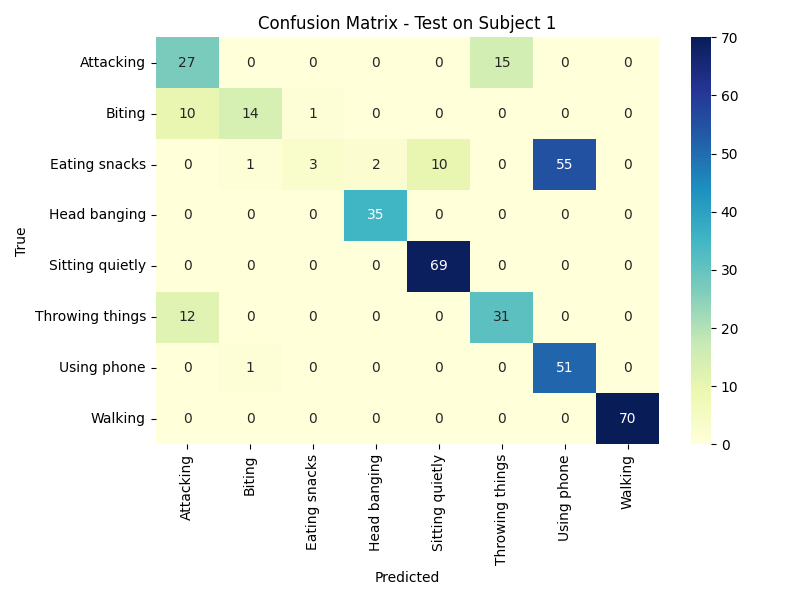


📄 Classification Report:
                 precision    recall  f1-score   support

      Attacking       0.55      0.64      0.59        42
         Biting       0.88      0.56      0.68        25
  Eating snacks       0.75      0.04      0.08        71
   Head banging       0.95      1.00      0.97        35
Sitting quietly       0.87      1.00      0.93        69
Throwing things       0.67      0.72      0.70        43
    Using phone       0.48      0.98      0.65        52
        Walking       1.00      1.00      1.00        70

       accuracy                           0.74       407
      macro avg       0.77      0.74      0.70       407
   weighted avg       0.78      0.74      0.69       407

📋 Fold 2: X_train shape = (1434, 30, 20), X_test shape = (404, 30, 20)
✅ Epoch 1: 🔥 New best model saved with F1: 0.2664
✅ Epoch 2: 🔥 New best model saved with F1: 0.2972
EarlyStopping counter: 1/20
EarlyStopping counter: 2/20
✅ Epoch 5: 🔥 New best model saved with F1: 0.3456
EarlyStopp

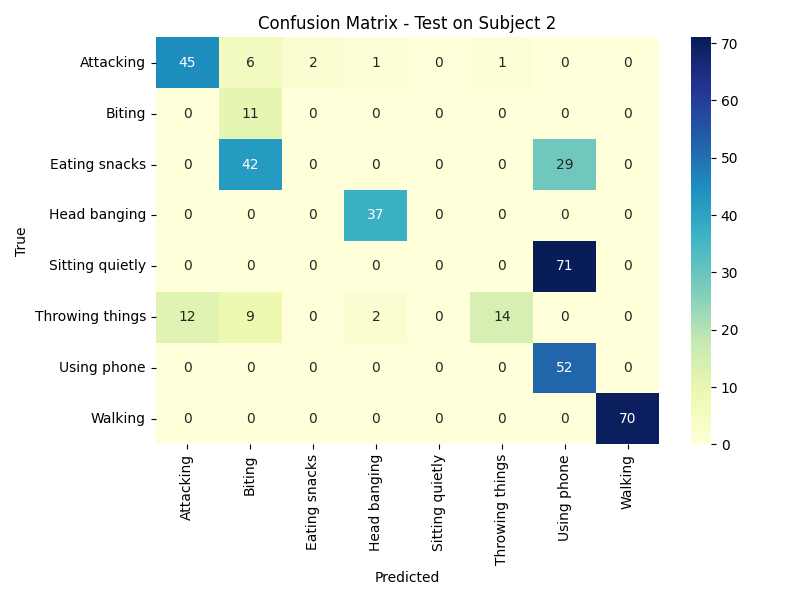


📄 Classification Report:
                 precision    recall  f1-score   support

      Attacking       0.79      0.82      0.80        55
         Biting       0.16      1.00      0.28        11
  Eating snacks       0.00      0.00      0.00        71
   Head banging       0.93      1.00      0.96        37
Sitting quietly       0.00      0.00      0.00        71
Throwing things       0.93      0.38      0.54        37
    Using phone       0.34      1.00      0.51        52
        Walking       1.00      1.00      1.00        70

       accuracy                           0.57       404
      macro avg       0.52      0.65      0.51       404
   weighted avg       0.50      0.57      0.49       404

📋 Fold 3: X_train shape = (1251, 30, 20), X_test shape = (588, 30, 20)


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


✅ Epoch 1: 🔥 New best model saved with F1: 0.3483
EarlyStopping counter: 1/20
EarlyStopping counter: 2/20
EarlyStopping counter: 3/20
✅ Epoch 5: 🔥 New best model saved with F1: 0.4583
✅ Epoch 6: 🔥 New best model saved with F1: 0.4622
✅ Epoch 7: 🔥 New best model saved with F1: 0.4750
✅ Epoch 8: 🔥 New best model saved with F1: 0.4846
✅ Epoch 9: 🔥 New best model saved with F1: 0.5003
✅ Epoch 10: 🔥 New best model saved with F1: 0.5356
✅ Epoch 11: 🔥 New best model saved with F1: 0.5610
EarlyStopping counter: 1/20
EarlyStopping counter: 2/20
EarlyStopping counter: 3/20
EarlyStopping counter: 4/20
EarlyStopping counter: 5/20
EarlyStopping counter: 6/20
EarlyStopping counter: 7/20
✅ Epoch 19: 🔥 New best model saved with F1: 0.5824
EarlyStopping counter: 1/20
EarlyStopping counter: 2/20
EarlyStopping counter: 3/20
✅ Epoch 23: 🔥 New best model saved with F1: 0.5903
EarlyStopping counter: 1/20
✅ Epoch 25: 🔥 New best model saved with F1: 0.5972
EarlyStopping counter: 1/20
✅ Epoch 27: 🔥 New best mo

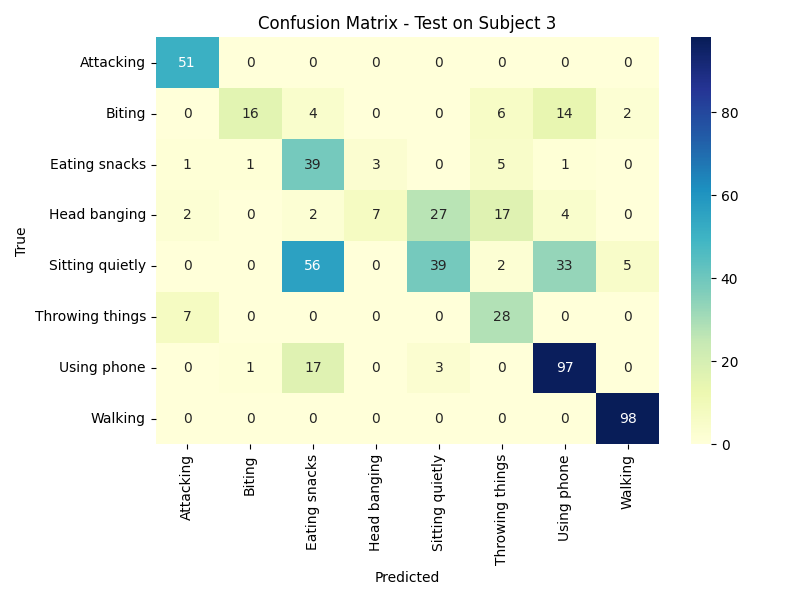


📄 Classification Report:
                 precision    recall  f1-score   support

      Attacking       0.84      1.00      0.91        51
         Biting       0.89      0.38      0.53        42
  Eating snacks       0.33      0.78      0.46        50
   Head banging       0.70      0.12      0.20        59
Sitting quietly       0.57      0.29      0.38       135
Throwing things       0.48      0.80      0.60        35
    Using phone       0.65      0.82      0.73       118
        Walking       0.93      1.00      0.97        98

       accuracy                           0.64       588
      macro avg       0.67      0.65      0.60       588
   weighted avg       0.68      0.64      0.61       588

📋 Fold 5: X_train shape = (1437, 30, 20), X_test shape = (402, 30, 20)
✅ Epoch 1: 🔥 New best model saved with F1: 0.2949
✅ Epoch 2: 🔥 New best model saved with F1: 0.5307
✅ Epoch 3: 🔥 New best model saved with F1: 0.5420
EarlyStopping counter: 1/20
EarlyStopping counter: 2/20
EarlyStopp

/tmp/ipython-input-28-1491181548.py:236: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(8, 6))


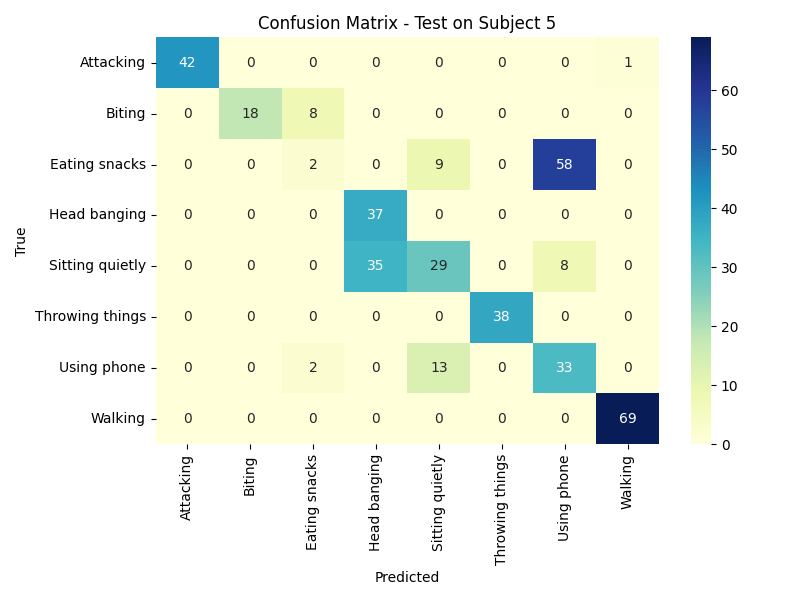


📄 Classification Report:
                 precision    recall  f1-score   support

      Attacking       1.00      0.98      0.99        43
         Biting       1.00      0.69      0.82        26
  Eating snacks       0.17      0.03      0.05        69
   Head banging       0.51      1.00      0.68        37
Sitting quietly       0.57      0.40      0.47        72
Throwing things       1.00      1.00      1.00        38
    Using phone       0.33      0.69      0.45        48
        Walking       0.99      1.00      0.99        69

       accuracy                           0.67       402
      macro avg       0.70      0.72      0.68       402
   weighted avg       0.65      0.67      0.63       402


📊 === KẾT QUẢ TRUNG BÌNH LOSO (LSTM) ===
Accuracy  : 0.6521
Precision : 0.6517
Recall    : 0.6521
F1        : 0.6050
Log_loss  : 1.2052


In [28]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, log_loss, classification_report, confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils.class_weight import compute_class_weight

# ==== CONFIG ====
subject_ids = [1, 2, 3, 5]
data_dir = "features"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

input_dim = 20
hidden_dim = 128
num_epochs = 300
batch_size = 32
lr = 1e-4
seq_len = 30
step_size = 10

model_type = 'LSTM'   # hoặc 'Transformer'

# ==== EarlyStopping ====
class EarlyStopping:
    def __init__(self, patience=20, verbose=False):
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False

    def __call__(self, score):
        if self.best_score is None or score > self.best_score:
            self.best_score = score
            self.counter = 0
        else:
            self.counter += 1
            if self.verbose:
                print(f"EarlyStopping counter: {self.counter}/{self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True

# ==== Mô hình ====
class LSTMClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes, num_layers=2, bidirectional=True, dropout=0.5):
        super(LSTMClassifier, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            dropout=dropout,
            bidirectional=bidirectional,
            batch_first=True
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * (2 if bidirectional else 1), num_classes)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        last_hidden = lstm_out[:, -1, :]
        out = self.dropout(last_hidden)
        return self.fc(out)

class TransformerClassifier(nn.Module):
    def __init__(self, input_dim, num_classes, d_model=128, nhead=4, num_layers=2, dim_feedforward=256, dropout=0.3):
        super(TransformerClassifier, self).__init__()
        self.input_fc = nn.Linear(input_dim, d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(d_model, num_classes)

    def forward(self, x):
        x = self.input_fc(x)
        x = self.transformer(x)
        x = x.mean(dim=1)
        x = self.dropout(x)
        return self.fc(x)

# ==== Sliding window ====
def create_sliding_windows(X, y, seq_len, step_size):
    X_seq, y_seq = [], []
    for label in np.unique(y):
        idx = np.where(y == label)[0]
        X_label = X[idx]
        y_label = y[idx]
        for i in range(0, len(X_label) - seq_len + 1, step_size):
            X_seq.append(X_label[i:i+seq_len])
            y_seq.append(y_label[i+seq_len-1])
    return np.array(X_seq), np.array(y_seq)

# ==== Training & Evaluation ====
def train_model(model, train_loader, criterion, optimizer):
    model.train()
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

def evaluate_model(model, X_test, y_test):
    model.eval()
    with torch.no_grad():
        X_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
        outputs = model(X_tensor)
        y_pred = outputs.argmax(dim=1).cpu().numpy()
        y_proba = torch.softmax(outputs, dim=1).cpu().numpy()
    return y_pred, y_proba

# ==== LOSO ====
all_metrics = {"accuracy": [], "precision": [], "recall": [], "f1": [], "log_loss": []}

for test_id in subject_ids:
    df_test = pd.read_csv(f"{data_dir}/cleaned_keypoints_with_labels_{test_id}_features.csv")
    df_train = pd.concat([
        pd.read_csv(f"{data_dir}/cleaned_keypoints_with_labels_{i}_features.csv")
        for i in subject_ids if i != test_id
    ], ignore_index=True)

    X_train, y_train = df_train.drop(columns=["action"]), df_train["action"]
    X_test, y_test = df_test.drop(columns=["action"]), df_test["action"]

    le = LabelEncoder()
    y_train_enc = le.fit_transform(y_train)
    y_test_enc = le.transform(y_test)

    imputer = SimpleImputer(strategy='mean')
    X_train = imputer.fit_transform(X_train)
    X_test = imputer.transform(X_test)

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    num_classes = len(le.classes_)

    X_train, y_train_enc = create_sliding_windows(X_train, y_train_enc, seq_len, step_size)
    X_test, y_test_enc = create_sliding_windows(X_test, y_test_enc, seq_len, step_size)

    print(f"📋 Fold {test_id}: X_train shape = {X_train.shape}, X_test shape = {X_test.shape}")

    train_dataset = torch.utils.data.TensorDataset(
        torch.tensor(X_train, dtype=torch.float32),
        torch.tensor(y_train_enc, dtype=torch.long)
    )
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    if model_type == 'LSTM':
        model = LSTMClassifier(
            input_dim=input_dim,
            hidden_dim=hidden_dim,
            num_classes=num_classes,
            num_layers=2,
            bidirectional=True,
            dropout=0.5
        ).to(device)
    else:
        model = TransformerClassifier(
            input_dim=input_dim,
            num_classes=num_classes,
            d_model=128,
            nhead=4,
            num_layers=2,
            dim_feedforward=256,
            dropout=0.3
        ).to(device)

    optimizer = optim.Adam(model.parameters(), lr=lr)
    weights = compute_class_weight('balanced', classes=np.unique(y_train_enc), y=y_train_enc)
    criterion = nn.CrossEntropyLoss(weight=torch.tensor(weights, dtype=torch.float32).to(device))

    best_model_path = f"best_model_{model_type}_subject_{test_id}.pt"
    best_f1 = 0.0
    early_stopping = EarlyStopping(patience=20, verbose=True)

    for epoch in range(num_epochs):
        train_model(model, train_loader, criterion, optimizer)
        y_pred_epoch, _ = evaluate_model(model, X_test, y_test_enc)
        f1_epoch = f1_score(y_test_enc, y_pred_epoch, average='weighted', zero_division=0)

        if f1_epoch > best_f1:
            best_f1 = f1_epoch
            torch.save(model.state_dict(), best_model_path)
            print(f"✅ Epoch {epoch+1}: 🔥 New best model saved with F1: {f1_epoch:.4f}")

        early_stopping(f1_epoch)
        if early_stopping.early_stop:
            print("⏳ Early stopping triggered.")
            break

    model.load_state_dict(torch.load(best_model_path))

    y_pred, y_proba = evaluate_model(model, X_test, y_test_enc)

    acc = accuracy_score(y_test_enc, y_pred)
    prec = precision_score(y_test_enc, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test_enc, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test_enc, y_pred, average='weighted', zero_division=0)
    loss = log_loss(y_test_enc, y_proba)

    print(f"\n📂 Fold: Train on [{', '.join(str(i) for i in subject_ids if i != test_id)}], Test on [{test_id}]")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall   : {rec:.4f}")
    print(f"  F1 Score : {f1:.4f}")
    print(f"  Log Loss : {loss:.4f}")

    all_metrics["accuracy"].append(acc)
    all_metrics["precision"].append(prec)
    all_metrics["recall"].append(rec)
    all_metrics["f1"].append(f1)
    all_metrics["log_loss"].append(loss)

    cm = confusion_matrix(y_test_enc, y_pred)
    cm_df = pd.DataFrame(cm, index=le.classes_, columns=le.classes_)
    print("\n🧩 Confusion Matrix:")
    print(cm_df)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_df, annot=True, fmt='d', cmap='YlGnBu')
    plt.title(f'Confusion Matrix - Test on Subject {test_id}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.show()

    print("\n📄 Classification Report:")
    print(classification_report(y_test_enc, y_pred, target_names=le.classes_))

print(f"\n📊 === KẾT QUẢ TRUNG BÌNH LOSO ({model_type}) ===")
for metric in all_metrics:
    print(f"{metric.capitalize():<10}: {np.mean(all_metrics[metric]):.4f}")


## Transformer

📋 Fold 1: X_train shape = (1430, 30, 20), X_test shape = (407, 30, 20)
✅ Epoch 1: 🔥 New best model saved with F1: 0.7516
EarlyStopping counter: 1/20
EarlyStopping counter: 2/20
EarlyStopping counter: 3/20
EarlyStopping counter: 4/20
EarlyStopping counter: 5/20
EarlyStopping counter: 6/20
EarlyStopping counter: 7/20
EarlyStopping counter: 8/20
EarlyStopping counter: 9/20
EarlyStopping counter: 10/20
EarlyStopping counter: 11/20
EarlyStopping counter: 12/20
EarlyStopping counter: 13/20
EarlyStopping counter: 14/20
EarlyStopping counter: 15/20
EarlyStopping counter: 16/20
EarlyStopping counter: 17/20
EarlyStopping counter: 18/20
EarlyStopping counter: 19/20
EarlyStopping counter: 20/20
⏳ Early stopping triggered.

📂 Fold: Train on [2, 3, 5], Test on [1]
  Accuracy : 0.7740
  Precision: 0.8077
  Recall   : 0.7740
  F1 Score : 0.7516
  Log Loss : 1.1050

🧩 Confusion Matrix:
                 Attacking  Biting  Eating snacks  Head banging  \
Attacking               42       0              0  

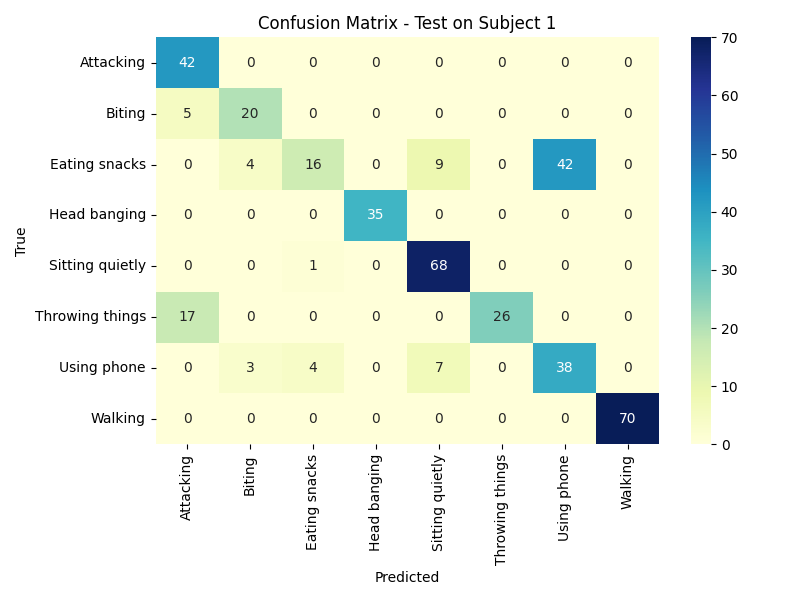


📄 Classification Report:
                 precision    recall  f1-score   support

      Attacking       0.66      1.00      0.79        42
         Biting       0.74      0.80      0.77        25
  Eating snacks       0.76      0.23      0.35        71
   Head banging       1.00      1.00      1.00        35
Sitting quietly       0.81      0.99      0.89        69
Throwing things       1.00      0.60      0.75        43
    Using phone       0.47      0.73      0.58        52
        Walking       1.00      1.00      1.00        70

       accuracy                           0.77       407
      macro avg       0.81      0.79      0.77       407
   weighted avg       0.81      0.77      0.75       407

📋 Fold 2: X_train shape = (1434, 30, 20), X_test shape = (404, 30, 20)
✅ Epoch 1: 🔥 New best model saved with F1: 0.3578
✅ Epoch 2: 🔥 New best model saved with F1: 0.3955
✅ Epoch 3: 🔥 New best model saved with F1: 0.5941
EarlyStopping counter: 1/20
EarlyStopping counter: 2/20
EarlyStopp

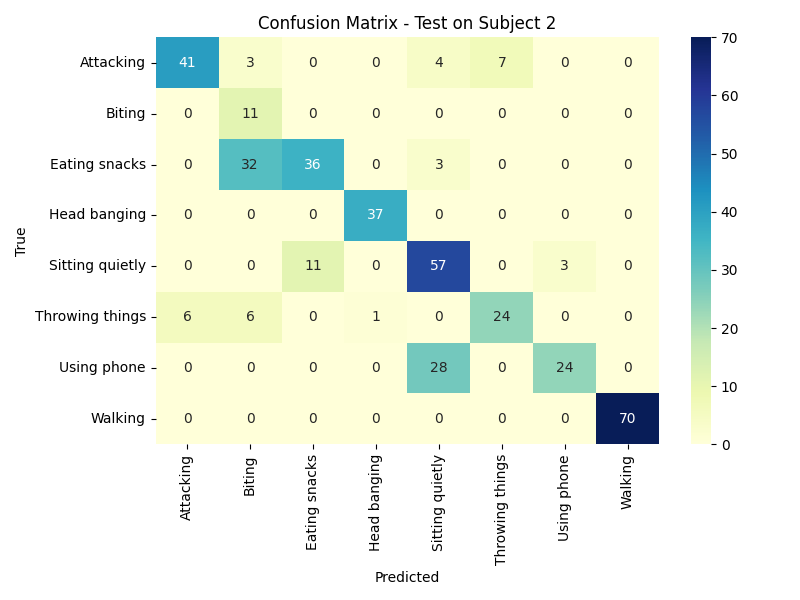


📄 Classification Report:
                 precision    recall  f1-score   support

      Attacking       0.87      0.75      0.80        55
         Biting       0.21      1.00      0.35        11
  Eating snacks       0.77      0.51      0.61        71
   Head banging       0.97      1.00      0.99        37
Sitting quietly       0.62      0.80      0.70        71
Throwing things       0.77      0.65      0.71        37
    Using phone       0.89      0.46      0.61        52
        Walking       1.00      1.00      1.00        70

       accuracy                           0.74       404
      macro avg       0.76      0.77      0.72       404
   weighted avg       0.82      0.74      0.76       404

📋 Fold 3: X_train shape = (1251, 30, 20), X_test shape = (588, 30, 20)
✅ Epoch 1: 🔥 New best model saved with F1: 0.4641
✅ Epoch 2: 🔥 New best model saved with F1: 0.4945
✅ Epoch 3: 🔥 New best model saved with F1: 0.5028
✅ Epoch 4: 🔥 New best model saved with F1: 0.5635
EarlyStopping co

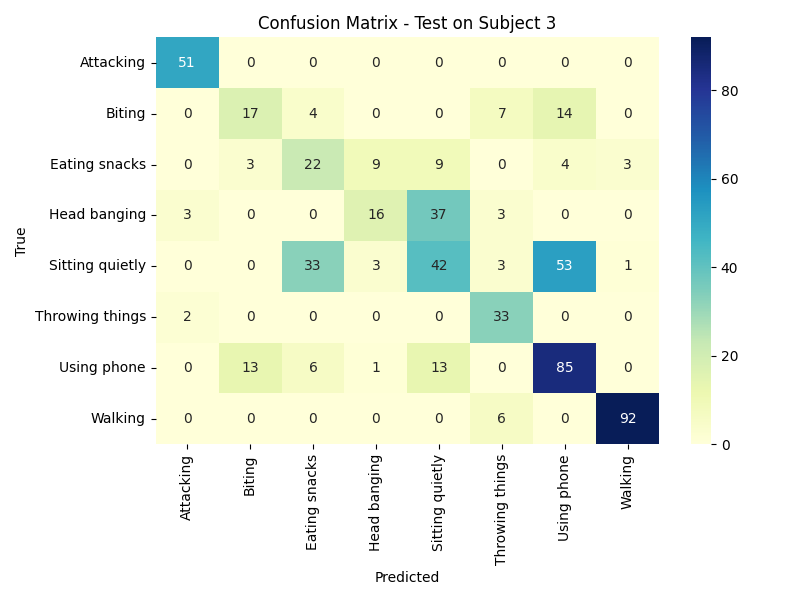


📄 Classification Report:
                 precision    recall  f1-score   support

      Attacking       0.91      1.00      0.95        51
         Biting       0.52      0.40      0.45        42
  Eating snacks       0.34      0.44      0.38        50
   Head banging       0.55      0.27      0.36        59
Sitting quietly       0.42      0.31      0.36       135
Throwing things       0.63      0.94      0.76        35
    Using phone       0.54      0.72      0.62       118
        Walking       0.96      0.94      0.95        98

       accuracy                           0.61       588
      macro avg       0.61      0.63      0.60       588
   weighted avg       0.60      0.61      0.59       588

📋 Fold 5: X_train shape = (1437, 30, 20), X_test shape = (402, 30, 20)
✅ Epoch 1: 🔥 New best model saved with F1: 0.5883
✅ Epoch 2: 🔥 New best model saved with F1: 0.5931
✅ Epoch 3: 🔥 New best model saved with F1: 0.6193
✅ Epoch 4: 🔥 New best model saved with F1: 0.6308
✅ Epoch 5: 🔥 New

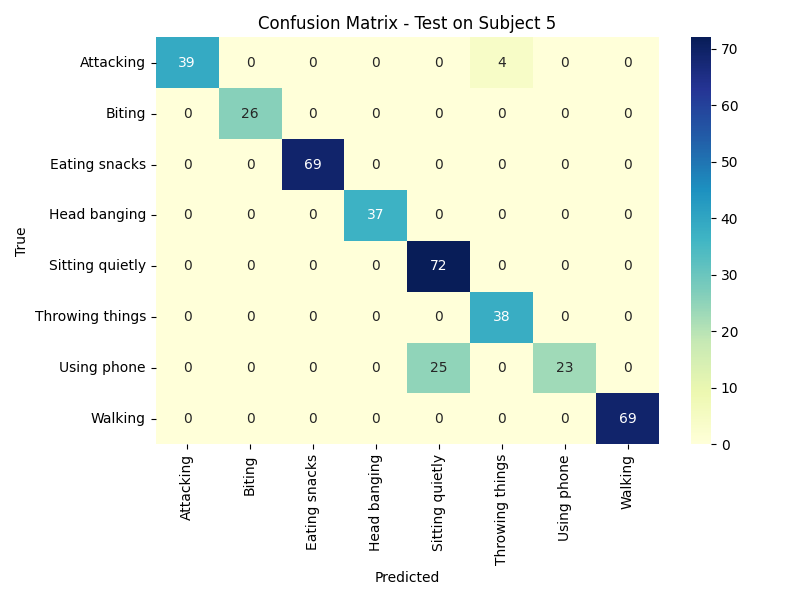


📄 Classification Report:
                 precision    recall  f1-score   support

      Attacking       1.00      0.91      0.95        43
         Biting       1.00      1.00      1.00        26
  Eating snacks       1.00      1.00      1.00        69
   Head banging       1.00      1.00      1.00        37
Sitting quietly       0.74      1.00      0.85        72
Throwing things       0.90      1.00      0.95        38
    Using phone       1.00      0.48      0.65        48
        Walking       1.00      1.00      1.00        69

       accuracy                           0.93       402
      macro avg       0.96      0.92      0.93       402
   weighted avg       0.94      0.93      0.92       402


📊 === KẾT QUẢ TRUNG BÌNH LOSO (Transformer) ===
Accuracy  : 0.7633
Precision : 0.7926
Recall    : 0.7633
F1        : 0.7556
Log_loss  : 0.8983


In [29]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, log_loss, classification_report, confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils.class_weight import compute_class_weight

# ==== CONFIG ====
subject_ids = [1, 2, 3, 5]
data_dir = "features"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

input_dim = 20
hidden_dim = 128
num_epochs = 300
batch_size = 32
lr = 1e-4
seq_len = 30
step_size = 10

model_type = 'Transformer'   # hoặc 'Transformer'

# ==== EarlyStopping ====
class EarlyStopping:
    def __init__(self, patience=20, verbose=False):
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False

    def __call__(self, score):
        if self.best_score is None or score > self.best_score:
            self.best_score = score
            self.counter = 0
        else:
            self.counter += 1
            if self.verbose:
                print(f"EarlyStopping counter: {self.counter}/{self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True

# ==== Mô hình ====
class LSTMClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes, num_layers=2, bidirectional=True, dropout=0.5):
        super(LSTMClassifier, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            dropout=dropout,
            bidirectional=bidirectional,
            batch_first=True
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * (2 if bidirectional else 1), num_classes)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        last_hidden = lstm_out[:, -1, :]
        out = self.dropout(last_hidden)
        return self.fc(out)

class TransformerClassifier(nn.Module):
    def __init__(self, input_dim, num_classes, d_model=128, nhead=4, num_layers=2, dim_feedforward=256, dropout=0.3):
        super(TransformerClassifier, self).__init__()
        self.input_fc = nn.Linear(input_dim, d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(d_model, num_classes)

    def forward(self, x):
        x = self.input_fc(x)
        x = self.transformer(x)
        x = x.mean(dim=1)
        x = self.dropout(x)
        return self.fc(x)

# ==== Sliding window ====
def create_sliding_windows(X, y, seq_len, step_size):
    X_seq, y_seq = [], []
    for label in np.unique(y):
        idx = np.where(y == label)[0]
        X_label = X[idx]
        y_label = y[idx]
        for i in range(0, len(X_label) - seq_len + 1, step_size):
            X_seq.append(X_label[i:i+seq_len])
            y_seq.append(y_label[i+seq_len-1])
    return np.array(X_seq), np.array(y_seq)

# ==== Training & Evaluation ====
def train_model(model, train_loader, criterion, optimizer):
    model.train()
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

def evaluate_model(model, X_test, y_test):
    model.eval()
    with torch.no_grad():
        X_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
        outputs = model(X_tensor)
        y_pred = outputs.argmax(dim=1).cpu().numpy()
        y_proba = torch.softmax(outputs, dim=1).cpu().numpy()
    return y_pred, y_proba

# ==== LOSO ====
all_metrics = {"accuracy": [], "precision": [], "recall": [], "f1": [], "log_loss": []}

for test_id in subject_ids:
    df_test = pd.read_csv(f"{data_dir}/cleaned_keypoints_with_labels_{test_id}_features.csv")
    df_train = pd.concat([
        pd.read_csv(f"{data_dir}/cleaned_keypoints_with_labels_{i}_features.csv")
        for i in subject_ids if i != test_id
    ], ignore_index=True)

    X_train, y_train = df_train.drop(columns=["action"]), df_train["action"]
    X_test, y_test = df_test.drop(columns=["action"]), df_test["action"]

    le = LabelEncoder()
    y_train_enc = le.fit_transform(y_train)
    y_test_enc = le.transform(y_test)

    imputer = SimpleImputer(strategy='mean')
    X_train = imputer.fit_transform(X_train)
    X_test = imputer.transform(X_test)

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    num_classes = len(le.classes_)

    X_train, y_train_enc = create_sliding_windows(X_train, y_train_enc, seq_len, step_size)
    X_test, y_test_enc = create_sliding_windows(X_test, y_test_enc, seq_len, step_size)

    print(f"📋 Fold {test_id}: X_train shape = {X_train.shape}, X_test shape = {X_test.shape}")

    train_dataset = torch.utils.data.TensorDataset(
        torch.tensor(X_train, dtype=torch.float32),
        torch.tensor(y_train_enc, dtype=torch.long)
    )
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    if model_type == 'LSTM':
        model = LSTMClassifier(
            input_dim=input_dim,
            hidden_dim=hidden_dim,
            num_classes=num_classes,
            num_layers=2,
            bidirectional=True,
            dropout=0.5
        ).to(device)
    else:
        model = TransformerClassifier(
            input_dim=input_dim,
            num_classes=num_classes,
            d_model=128,
            nhead=4,
            num_layers=2,
            dim_feedforward=256,
            dropout=0.3
        ).to(device)

    optimizer = optim.Adam(model.parameters(), lr=lr)
    weights = compute_class_weight('balanced', classes=np.unique(y_train_enc), y=y_train_enc)
    criterion = nn.CrossEntropyLoss(weight=torch.tensor(weights, dtype=torch.float32).to(device))

    best_model_path = f"best_model_{model_type}_subject_{test_id}.pt"
    best_f1 = 0.0
    early_stopping = EarlyStopping(patience=20, verbose=True)

    for epoch in range(num_epochs):
        train_model(model, train_loader, criterion, optimizer)
        y_pred_epoch, _ = evaluate_model(model, X_test, y_test_enc)
        f1_epoch = f1_score(y_test_enc, y_pred_epoch, average='weighted', zero_division=0)

        if f1_epoch > best_f1:
            best_f1 = f1_epoch
            torch.save(model.state_dict(), best_model_path)
            print(f"✅ Epoch {epoch+1}: 🔥 New best model saved with F1: {f1_epoch:.4f}")

        early_stopping(f1_epoch)
        if early_stopping.early_stop:
            print("⏳ Early stopping triggered.")
            break

    model.load_state_dict(torch.load(best_model_path))

    y_pred, y_proba = evaluate_model(model, X_test, y_test_enc)

    acc = accuracy_score(y_test_enc, y_pred)
    prec = precision_score(y_test_enc, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test_enc, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test_enc, y_pred, average='weighted', zero_division=0)
    loss = log_loss(y_test_enc, y_proba)

    print(f"\n📂 Fold: Train on [{', '.join(str(i) for i in subject_ids if i != test_id)}], Test on [{test_id}]")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall   : {rec:.4f}")
    print(f"  F1 Score : {f1:.4f}")
    print(f"  Log Loss : {loss:.4f}")

    all_metrics["accuracy"].append(acc)
    all_metrics["precision"].append(prec)
    all_metrics["recall"].append(rec)
    all_metrics["f1"].append(f1)
    all_metrics["log_loss"].append(loss)

    cm = confusion_matrix(y_test_enc, y_pred)
    cm_df = pd.DataFrame(cm, index=le.classes_, columns=le.classes_)
    print("\n🧩 Confusion Matrix:")
    print(cm_df)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_df, annot=True, fmt='d', cmap='YlGnBu')
    plt.title(f'Confusion Matrix - Test on Subject {test_id}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.show()

    print("\n📄 Classification Report:")
    print(classification_report(y_test_enc, y_pred, target_names=le.classes_))

print(f"\n📊 === KẾT QUẢ TRUNG BÌNH LOSO ({model_type}) ===")
for metric in all_metrics:
    print(f"{metric.capitalize():<10}: {np.mean(all_metrics[metric]):.4f}")
